<a href="https://colab.research.google.com/github/valeriaacostaleal/Econometria/blob/main/Proyecto_Final_Econometria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final Econometría — Panel Data, Series de Tiempo y Forecast
**Valeria Acosta — A00818610**  
Maestría en Finanzas | EGADE Business School | Marzo 2026

**Portafolio:** NVDA (dependiente), AAPL, META, AMD, INTC, PLTR, LMT, GD, JPM, JNJ, XOM  
**Datos:** Refinitiv Financial Summary (trimestrales) + Yahoo Finance (precios diarios)


## 1. Instalación y Carga de Librerías


In [4]:
# Instalar librerías necesarias en Colab
!pip install linearmodels pmdarima arch yfinance -q


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Panel Data
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from linearmodels.panel import compare

# Series de Tiempo
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import yfinance as yf

# GARCH
from arch import arch_model

# Config visual
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
palette = ['#FF6B35', '#004E89', '#2A9D8F', '#E76F51', '#264653',
           '#F4A261', '#606C38', '#BC6C25', '#023047', '#8338EC', '#FB5607']

print("Librerías cargadas correctamente")


Librerías cargadas correctamente


## 2. Carga de Datos

### 2.1 Datos trimestrales (Refinitiv Financial Summary)
El archivo `panel_data_enhanced.csv` contiene datos trimestrales de los 11 Financial Summaries de Refinitiv, con variables como Revenue, Net Income, EPS, márgenes, ROE, ROA, y variables derivadas (crecimiento YoY, retornos trimestrales).


In [6]:
# Subir el archivo panel_data_enhanced.csv a Colab
# Opción 1: Upload manual
from google.colab import files
uploaded = files.upload()  # Seleccionar panel_data_enhanced.csv

panel = pd.read_csv('panel_data_enhanced.csv', parse_dates=['Date'])
panel = panel.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f"Panel: {panel.shape[0]} observaciones, {panel.shape[1]} variables")
print(f"Empresas: {panel.Ticker.nunique()} — {sorted(panel.Ticker.unique())}")
print(f"Periodo: {panel.Date.min().date()} a {panel.Date.max().date()}")
print(f"\nVariables: {list(panel.columns)}")


Saving panel_data_enhanced.csv to panel_data_enhanced (2).csv
Panel: 188 observaciones, 26 variables
Empresas: 11 — ['AAPL', 'AMD', 'GD', 'INTC', 'JNJ', 'JPM', 'LMT', 'META', 'NVDA', 'PLTR', 'XOM']
Periodo: 2021-09-25 a 2026-01-25

Variables: ['Ticker', 'Date', 'Revenue', 'OperatingProfit', 'EBITDA', 'NetIncome', 'TotalAssets', 'CommonEquity', 'EPS', 'OperatingCashFlow', 'CapEx', 'GrossMargin', 'OperatingMargin', 'NetMargin', 'ROE_TTM', 'ROA_TTM', 'CurrentRatio', 'DebtToEquity', 'MarketCap', 'RevenueGrowthQoQ', 'RevenueGrowthYoY', 'EPSGrowthYoY', 'NetIncomeGrowthYoY', 'StockReturnQoQ', 'LogAssets', 'FreeCashFlow']


### 2.2 Datos de precios diarios (Yahoo Finance)


In [7]:
# Descargar precios diarios de las 11 acciones
tickers = ['NVDA', 'AAPL', 'META', 'AMD', 'INTC', 'PLTR', 'LMT', 'GD', 'JPM', 'JNJ', 'XOM']

precios = yf.download(tickers, start='2021-03-01', end='2026-03-15', auto_adjust=True)['Close']
precios = precios.dropna()

print(f"Precios diarios: {precios.shape[0]} días, {precios.shape[1]} acciones")
print(f"Periodo: {precios.index[0].date()} a {precios.index[-1].date()}")


[*********************100%***********************]  11 of 11 completed

Precios diarios: 1266 días, 11 acciones
Periodo: 2021-03-01 a 2026-03-13


In [8]:
# Calcular retornos trimestrales reales para el panel
# Mapear cada fecha de quarter-end al precio más cercano
def get_nearest_price(prices_series, target_date, window=7):
    for offset in range(window + 1):
        for d in [target_date + pd.Timedelta(days=offset),
                  target_date - pd.Timedelta(days=offset)]:
            if d in prices_series.index:
                return prices_series.loc[d]
    return np.nan

panel['StockReturn'] = np.nan
for tk in tickers:
    if tk not in precios.columns:
        continue
    mask = panel['Ticker'] == tk
    dates = panel.loc[mask, 'Date'].values
    for i, dt in enumerate(dates):
        dt = pd.Timestamp(dt)
        price_now = get_nearest_price(precios[tk], dt)
        if i == 0 or pd.isna(price_now):
            continue
        prev_dt = pd.Timestamp(dates[i-1])
        price_prev = get_nearest_price(precios[tk], prev_dt)
        if not pd.isna(price_prev) and price_prev > 0:
            panel.loc[mask & (panel['Date'] == dt), 'StockReturn'] = (price_now / price_prev - 1) * 100

print(f"Retornos trimestrales calculados: {panel.StockReturn.notna().sum()} de {len(panel)}")


Retornos trimestrales calculados: 177 de 188


---
# PARTE 1: Panel Data — Reportes Trimestrales

El análisis de panel data combina la dimensión transversal (11 empresas) con la temporal (17 trimestres) para evaluar cómo los fundamentales financieros se relacionan con el retorno bursátil, controlando por diferencias no observables entre compañías.

A diferencia de las regresiones de retornos diarios del R Markdown (que capturan comovimientos de mercado), aquí evaluamos relaciones fundamentales de mediano plazo.


## 3. Análisis Exploratorio del Panel


In [9]:
# Resumen por empresa
summary = panel.groupby('Ticker').agg(
    Trimestres=('Revenue', 'count'),
    Revenue_Prom=('Revenue', 'mean'),
    NetMargin_Prom=('NetMargin', 'mean'),
    ROE_Prom=('ROE_TTM', 'mean'),
    EPS_Ultimo=('EPS', 'last'),
    Return_Prom=('StockReturn', 'mean')
).round(2)

print("Resumen por empresa (promedios trimestrales):")
print(summary.to_string())


Resumen por empresa (promedios trimestrales):
        Trimestres  Revenue_Prom  NetMargin_Prom  ROE_Prom  EPS_Ultimo  Return_Prom
Ticker                                                                             
AAPL            18     100662.50           25.96    157.44        2.84         5.00
AMD             17       6560.65            7.54      6.72        1.01         5.16
GD              17      11308.06            8.14     18.16        4.16         3.98
INTC            17      14339.06           -4.36      1.24       -0.12         0.81
JNJ             17      21489.59           19.88     23.16        2.09         2.40
JPM             17      39071.06           31.99     16.59        4.63         5.92
LMT             17      17492.65            8.48     71.74        5.80         3.28
META            17      38273.29           31.14     30.46        8.15         7.49
NVDA            17      25998.47           42.71     76.75        1.76        17.49
PLTR            17        700.

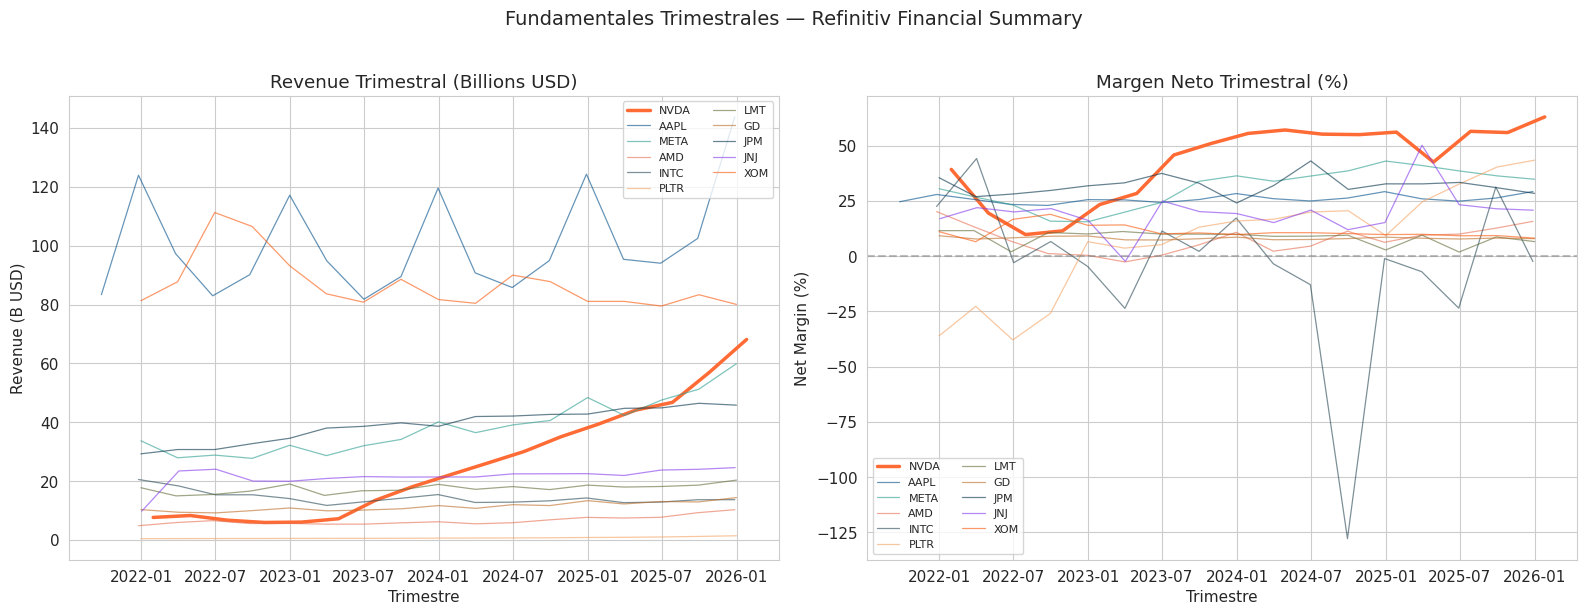

In [10]:
# Evolución de Revenue trimestral
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, tk in enumerate(tickers):
    data = panel[panel.Ticker == tk]
    axes[0].plot(data.Date, data.Revenue / 1000, label=tk, color=palette[i],
                 linewidth=2.5 if tk == 'NVDA' else 0.9,
                 alpha=1.0 if tk == 'NVDA' else 0.6)

axes[0].set_title('Revenue Trimestral (Billions USD)')
axes[0].set_xlabel('Trimestre')
axes[0].set_ylabel('Revenue (B USD)')
axes[0].legend(fontsize=8, ncol=2)

# Net Margin
for i, tk in enumerate(tickers):
    data = panel[panel.Ticker == tk].dropna(subset=['NetMargin'])
    axes[1].plot(data.Date, data.NetMargin, label=tk, color=palette[i],
                 linewidth=2.5 if tk == 'NVDA' else 0.9,
                 alpha=1.0 if tk == 'NVDA' else 0.6)

axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Margen Neto Trimestral (%)')
axes[1].set_xlabel('Trimestre')
axes[1].set_ylabel('Net Margin (%)')
axes[1].legend(fontsize=8, ncol=2)

plt.suptitle('Fundamentales Trimestrales — Refinitiv Financial Summary', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 4. Modelos de Panel Data


In [11]:
# Preparar datos para modelos de panel
# Eliminar observaciones con NAs en variables clave
vars_modelo = ['StockReturn', 'RevenueGrowthYoY', 'NetMargin', 'ROE_TTM', 'LogAssets']
panel_clean = panel.dropna(subset=vars_modelo).copy()

# Crear MultiIndex para linearmodels
panel_clean = panel_clean.set_index(['Ticker', 'Date'])

print(f"Observaciones para modelos: {len(panel_clean)}")
print(f"Empresas: {panel_clean.index.get_level_values(0).nunique()}")
print(f"Trimestres: {panel_clean.index.get_level_values(1).nunique()}")


Observaciones para modelos: 143
Empresas: 11
Trimestres: 51


### 4.1 Pooled OLS
El Pooled OLS trata todas las observaciones como independientes, sin considerar la estructura de panel. Sirve como baseline.


In [12]:
# Definir variables
y = panel_clean['StockReturn']
X = panel_clean[['RevenueGrowthYoY', 'NetMargin', 'ROE_TTM', 'LogAssets']]
from statsmodels.tools import add_constant
X_const = add_constant(X)

# Pooled OLS
pooled = PooledOLS(y, X_const).fit(cov_type='clustered', cluster_entity=True)
print("=" * 70)
print("MODELO 1: POOLED OLS")
print("=" * 70)
print(pooled.summary)


MODELO 1: POOLED OLS
                          PooledOLS Estimation Summary                          
Dep. Variable:            StockReturn   R-squared:                        0.1440
Estimator:                  PooledOLS   R-squared (Between):              0.7159
No. Observations:                 143   R-squared (Within):               0.0219
Date:                Tue, Mar 17 2026   R-squared (Overall):              0.1440
Time:                        02:36:41   Log-likelihood                   -632.39
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.8021
Entities:                          11   P-value                           0.0002
Avg Obs:                       13.000   Distribution:                   F(4,138)
Min Obs:                       12.000                                           
Max Obs:                       14.000   F-statistic (robust):             39.703
       

### 4.2 Efectos Fijos (Fixed Effects)
Controla por características no observables de cada empresa que no cambian en el tiempo (sector, cultura corporativa, tipo de producto). Es el modelo preferido cuando sospechamos que estas diferencias están correlacionadas con las variables independientes.


In [13]:
# Fixed Effects
fe = PanelOLS(y, X, entity_effects=True).fit(cov_type='clustered', cluster_entity=True)
print("=" * 70)
print("MODELO 2: EFECTOS FIJOS (Fixed Effects)")
print("=" * 70)
print(fe.summary)


MODELO 2: EFECTOS FIJOS (Fixed Effects)
                          PanelOLS Estimation Summary                           
Dep. Variable:            StockReturn   R-squared:                        0.0574
Estimator:                   PanelOLS   R-squared (Between):             -281.05
No. Observations:                 143   R-squared (Within):               0.0574
Date:                Tue, Mar 17 2026   R-squared (Overall):             -96.455
Time:                        02:36:41   Log-likelihood                   -625.43
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.9495
Entities:                          11   P-value                           0.1062
Avg Obs:                       13.000   Distribution:                   F(4,128)
Min Obs:                       12.000                                           
Max Obs:                       14.000   F-statistic (robust):        

### 4.3 Efectos Aleatorios (Random Effects)
Asume que las diferencias entre empresas no están correlacionadas con las variables explicativas. Es más eficiente si el supuesto se cumple.


In [14]:
# Random Effects
re = RandomEffects(y, X_const).fit(cov_type='clustered', cluster_entity=True)
print("=" * 70)
print("MODELO 3: EFECTOS ALEATORIOS (Random Effects)")
print("=" * 70)
print(re.summary)


MODELO 3: EFECTOS ALEATORIOS (Random Effects)
                        RandomEffects Estimation Summary                        
Dep. Variable:            StockReturn   R-squared:                        0.1271
Estimator:              RandomEffects   R-squared (Between):              0.7066
No. Observations:                 143   R-squared (Within):               0.0238
Date:                Tue, Mar 17 2026   R-squared (Overall):              0.1438
Time:                        02:36:42   Log-likelihood                   -631.68
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.0217
Entities:                          11   P-value                           0.0008
Avg Obs:                       13.000   Distribution:                   F(4,138)
Min Obs:                       12.000                                           
Max Obs:                       14.000   F-statistic (robust):  

### 4.4 Test de Hausman: FE vs RE


In [15]:
# Test de Hausman manual
# H0: RE es consistente (diferencias no son sistemáticas)
# H1: FE es necesario (diferencias son sistemáticas)
from scipy import stats

# Extraer coeficientes comunes
common_vars = [v for v in fe.params.index if v in re.params.index]
b_fe = fe.params[common_vars].values
b_re = re.params[common_vars].values
var_diff = np.diag(fe.cov[common_vars].loc[common_vars].values - re.cov[common_vars].loc[common_vars].values)

# Hausman statistic
diff = b_fe - b_re
hausman_stat = float(diff @ np.linalg.pinv(np.diag(np.abs(var_diff))) @ diff)
hausman_pval = 1 - stats.chi2.cdf(hausman_stat, df=len(common_vars))

print("Test de Hausman (FE vs RE)")
print("=" * 40)
print(f"Chi-cuadrado: {hausman_stat:.4f}")
print(f"p-value: {hausman_pval:.4f}")
print(f"Grados de libertad: {len(common_vars)}")
if hausman_pval < 0.05:
    print("→ Se rechaza H0: usar Efectos Fijos")
    modelo_preferido = "FE"
else:
    print("→ No se rechaza H0: Efectos Aleatorios es consistente")
    modelo_preferido = "RE"


Test de Hausman (FE vs RE)
Chi-cuadrado: 7.8052
p-value: 0.0990
Grados de libertad: 4
→ No se rechaza H0: Efectos Aleatorios es consistente


### 4.5 Modelo extendido con más variables


In [16]:
# Agregar más fundamentales al modelo
vars_ext = ['RevenueGrowthYoY', 'NetMargin', 'ROE_TTM', 'LogAssets', 'OperatingMargin']
panel_ext = panel.dropna(subset=['StockReturn'] + vars_ext).copy()
panel_ext = panel_ext.set_index(['Ticker', 'Date'])

y_ext = panel_ext['StockReturn']
X_ext = panel_ext[vars_ext]

fe_ext = PanelOLS(y_ext, X_ext, entity_effects=True).fit(cov_type='clustered', cluster_entity=True)
print("=" * 70)
print("MODELO 4: EFECTOS FIJOS EXTENDIDO")
print("=" * 70)
print(fe_ext.summary)


MODELO 4: EFECTOS FIJOS EXTENDIDO
                          PanelOLS Estimation Summary                           
Dep. Variable:            StockReturn   R-squared:                        0.0865
Estimator:                   PanelOLS   R-squared (Between):             -55.273
No. Observations:                 130   R-squared (Within):               0.0865
Date:                Tue, Mar 17 2026   R-squared (Overall):             -18.612
Time:                        02:36:42   Log-likelihood                   -571.51
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.1771
Entities:                          10   P-value                           0.0614
Avg Obs:                       13.000   Distribution:                   F(5,115)
Min Obs:                       12.000                                           
Max Obs:                       14.000   F-statistic (robust):             2

### 4.6 Comparación de modelos


In [17]:
# Tabla comparativa
print("Comparación de Modelos de Panel Data")
print("=" * 60)
print(f"{'Métrica':<25} {'Pooled':>10} {'FE':>10} {'RE':>10}")
print("-" * 60)
print(f"{'R²':<25} {pooled.rsquared:>10.4f} {fe.rsquared:>10.4f} {re.rsquared:>10.4f}")
print(f"{'Observaciones':<25} {pooled.nobs:>10d} {fe.nobs:>10d} {re.nobs:>10d}")
print(f"{'Modelo preferido':<25} {'':>10} {'← Hausman':>10}" if modelo_preferido == "FE" else f"{'Modelo preferido':<25} {'':>10} {'':>10} {'← Hausman':>10}")


Comparación de Modelos de Panel Data
Métrica                       Pooled         FE         RE
------------------------------------------------------------
R²                            0.1440     0.0574     0.1271
Observaciones                    143        143        143
Modelo preferido                                 ← Hausman


### 4.7 Interpretación del Panel Data

El panel data complementa las regresiones de retornos diarios al pasar de "¿qué acciones se mueven juntas?" (correlación de mercado) a "¿qué fundamentales importan para el retorno?" (relación estructura-desempeño).

Los efectos fijos capturan las diferencias estructurales entre sectores que en la regresión diaria se manifestaban como correlaciones negativas (NVDA vs JNJ) o cercanas a cero (NVDA vs LMT). Al controlar por estos efectos, podemos aislar si las variaciones en crecimiento de revenue, márgenes y ROE realmente explican las diferencias en retornos, o si todo se reduce a pertenecer a un sector u otro.

La conexión con HowTheMarketWorks es directa: si el modelo muestra que el crecimiento de revenue es el predictor más fuerte del retorno trimestral, eso valida la decisión de sobre-ponderar empresas con momentum de revenue positivo (como NVDA y META) frente a empresas con fundamentales estancados.


---
# PARTE 2: Series de Tiempo y Forecast

En esta sección modelamos cada una de las 11 acciones con modelos ARIMA para capturar la estructura temporal de los precios y generar pronósticos (forecast).

Para cada acción se aplican:
- Pruebas de estacionariedad (ADF y KPSS)
- Análisis de autocorrelación (ACF y PACF)
- Selección automática del mejor modelo ARIMA
- Forecast a 30 días con intervalos de confianza


## 5. Preparación de datos de precios


In [18]:
# Usar precios de cierre diarios ya descargados
# Calcular log-precios y retornos
log_precios = np.log(precios)
retornos_diarios = precios.pct_change().dropna() * 100

print(f"Precios diarios: {precios.shape[0]} observaciones")
print(f"Periodo: {precios.index[0].date()} a {precios.index[-1].date()}")
print(f"\nVolatilidad diaria (desv. est. retornos %):")
vol = retornos_diarios.std().sort_values(ascending=False)
for tk, v in vol.items():
    print(f"  {tk}: {v:.2f}%")


Precios diarios: 1266 observaciones
Periodo: 2021-03-01 a 2026-03-13

Volatilidad diaria (desv. est. retornos %):
  PLTR: 4.13%
  AMD: 3.36%
  NVDA: 3.27%
  INTC: 3.02%
  META: 2.74%
  AAPL: 1.74%
  XOM: 1.68%
  JPM: 1.53%
  LMT: 1.42%
  GD: 1.26%
  JNJ: 1.05%


## 6. Análisis de Series de Tiempo por Acción


In [19]:
def analizar_accion(ticker, precios_df, forecast_days=30):
    """Análisis completo de series de tiempo para una acción."""
    serie = precios_df[ticker].dropna()
    retornos = serie.pct_change().dropna() * 100

    print(f"\n{'='*70}")
    print(f"ANÁLISIS DE SERIES DE TIEMPO: {ticker}")
    print(f"{'='*70}")
    print(f"Observaciones: {len(serie)} | Periodo: {serie.index[0].date()} a {serie.index[-1].date()}")

    # --- Pruebas de Estacionariedad ---
    print(f"\n--- Pruebas de Estacionariedad (precios de cierre) ---")

    # ADF
    adf_result = adfuller(serie, autolag='AIC')
    adf_stat, adf_pval = adf_result[0], adf_result[1]
    print(f"ADF Statistic: {adf_stat:.4f} | p-value: {adf_pval:.4f}", end="")
    print(f" → {'Estacionaria' if adf_pval < 0.05 else 'NO estacionaria'}")

    # KPSS
    kpss_result = kpss(serie, regression='ct', nlags='auto')
    kpss_stat, kpss_pval = kpss_result[0], kpss_result[1]
    print(f"KPSS Statistic: {kpss_stat:.4f} | p-value: {kpss_pval:.4f}", end="")
    print(f" → {'NO estacionaria' if kpss_pval < 0.05 else 'Estacionaria'}")

    # --- ACF y PACF ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'{ticker} — Estructura Temporal', fontsize=14, fontweight='bold')

    axes[0, 0].plot(serie, color=palette[0], linewidth=0.7)
    axes[0, 0].set_title('Precio de Cierre')
    axes[0, 0].set_ylabel('USD')

    axes[0, 1].plot(retornos, color=palette[1], linewidth=0.5, alpha=0.7)
    axes[0, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0, 1].set_title('Retornos Diarios (%)')

    plot_acf(serie, lags=30, ax=axes[1, 0], color=palette[2])
    axes[1, 0].set_title('ACF — Precios')

    plot_pacf(serie, lags=30, ax=axes[1, 1], color=palette[3], method='ywm')
    axes[1, 1].set_title('PACF — Precios')

    plt.tight_layout()
    plt.show()

    # --- Modelo ARIMA con auto_arima ---
    print(f"\n--- Selección de Modelo ARIMA (auto_arima) ---")
    modelo_auto = auto_arima(serie, seasonal=False, stepwise=True,
                             suppress_warnings=True, error_action='ignore',
                             max_p=5, max_q=5, max_d=2,
                             information_criterion='aic', trace=False)

    order = modelo_auto.order
    print(f"Mejor modelo: ARIMA{order}")
    print(f"AIC: {modelo_auto.aic():.2f}")
    print(f"BIC: {modelo_auto.bic():.2f}")

    # Ajustar con statsmodels para diagnósticos completos
    modelo = ARIMA(serie, order=order).fit()
    print(f"\nResumen del modelo:")
    print(modelo.summary().tables[1])

    # Diagnósticos
    residuos = modelo.resid
    lb_stat = sm_diagnostic_ljungbox(residuos, lags=[10], return_df=True)
    print(f"\nLjung-Box (lag 10): stat={lb_stat['lb_stat'].values[0]:.2f}, p-value={lb_stat['lb_pvalue'].values[0]:.4f}")

    # --- Forecast ---
    print(f"\n--- Forecast a {forecast_days} días ---")
    forecast_result = modelo.get_forecast(steps=forecast_days)
    forecast_mean = forecast_result.predicted_mean
    forecast_ci = forecast_result.conf_int(alpha=0.05)

    last_date = serie.index[-1]
    forecast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days)

    print(f"Último precio: ${serie.iloc[-1]:.2f}")
    print(f"Forecast día 5: ${forecast_mean.iloc[4]:.2f}")
    print(f"Forecast día 15: ${forecast_mean.iloc[14]:.2f}")
    print(f"Forecast día 30: ${forecast_mean.iloc[-1]:.2f}")

    # Gráfica de forecast
    fig, ax = plt.subplots(figsize=(14, 6))
    # Últimos 60 días + forecast
    serie_tail = serie.iloc[-60:]
    ax.plot(serie_tail.index, serie_tail.values, color=palette[0], linewidth=1.5, label='Histórico')
    ax.plot(forecast_dates, forecast_mean.values, color=palette[3], linewidth=2, label='Forecast')
    ax.fill_between(forecast_dates,
                     forecast_ci.iloc[:, 0].values,
                     forecast_ci.iloc[:, 1].values,
                     alpha=0.2, color=palette[3], label='IC 95%')
    ax.axvline(x=last_date, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{ticker} — Forecast ARIMA{order} ({forecast_days} días)', fontsize=13)
    ax.set_ylabel('Precio (USD)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    return {
        'ticker': ticker,
        'adf_stat': adf_stat, 'adf_pval': adf_pval,
        'kpss_stat': kpss_stat, 'kpss_pval': kpss_pval,
        'order': order,
        'aic': modelo_auto.aic(),
        'forecast_30d': forecast_mean.iloc[-1],
        'last_price': serie.iloc[-1]
    }

# Importar diagnóstico de Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox as sm_diagnostic_ljungbox



ANÁLISIS DE SERIES DE TIEMPO: NVDA
Observaciones: 1266 | Periodo: 2021-03-01 a 2026-03-13

--- Pruebas de Estacionariedad (precios de cierre) ---
ADF Statistic: 0.0289 | p-value: 0.9609 → NO estacionaria
KPSS Statistic: 1.1103 | p-value: 0.0100 → NO estacionaria


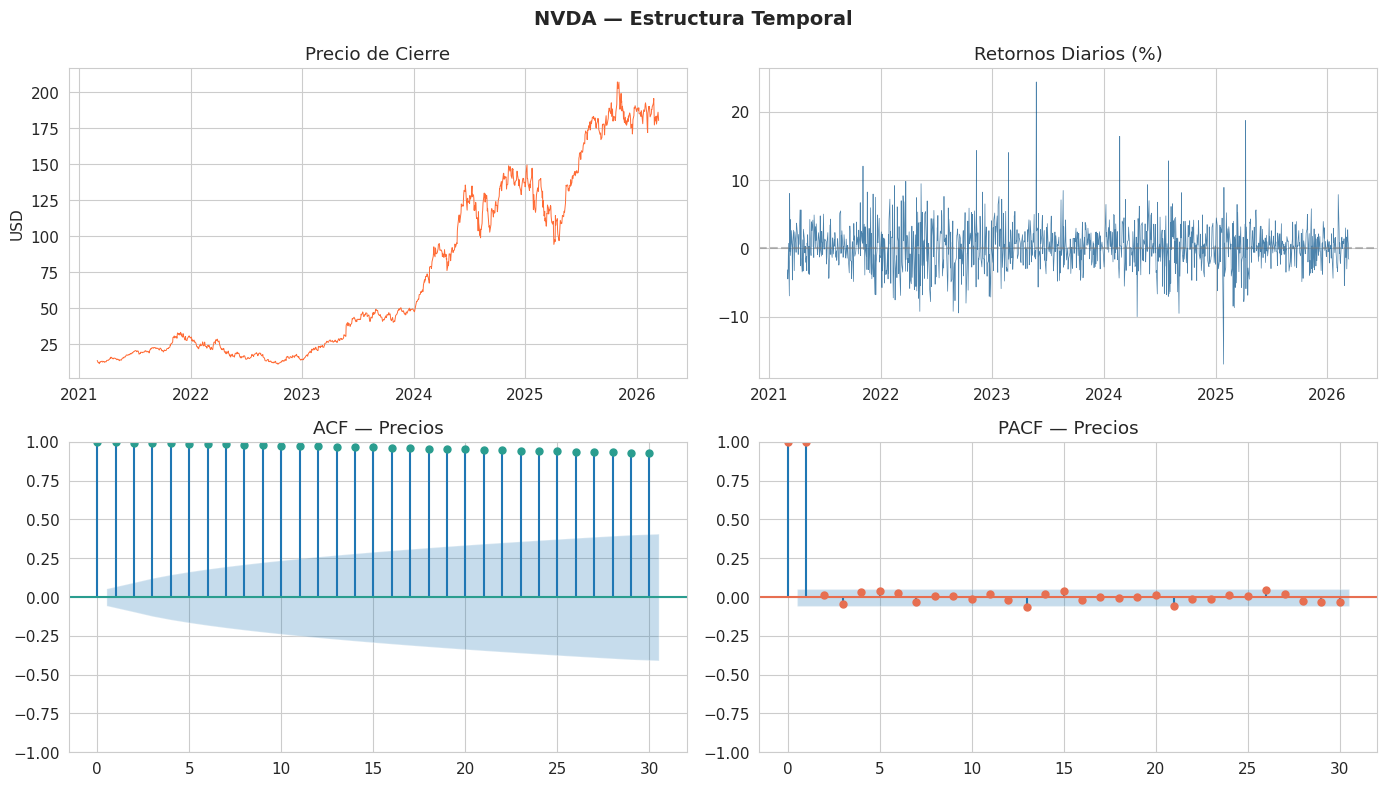


--- Selección de Modelo ARIMA (auto_arima) ---
Mejor modelo: ARIMA(4, 1, 0)
AIC: 6055.25
BIC: 6086.11

Resumen del modelo:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0739      0.016     -4.709      0.000      -0.105      -0.043
ar.L2          0.0693      0.019      3.726      0.000       0.033       0.106
ar.L3         -0.0771      0.020     -3.858      0.000      -0.116      -0.038
ar.L4         -0.0827      0.018     -4.507      0.000      -0.119      -0.047
sigma2         6.9781      0.128     54.516      0.000       6.727       7.229

Ljung-Box (lag 10): stat=4.48, p-value=0.9229

--- Forecast a 30 días ---
Último precio: $180.25
Forecast día 5: $180.64
Forecast día 15: $180.56
Forecast día 30: $180.56


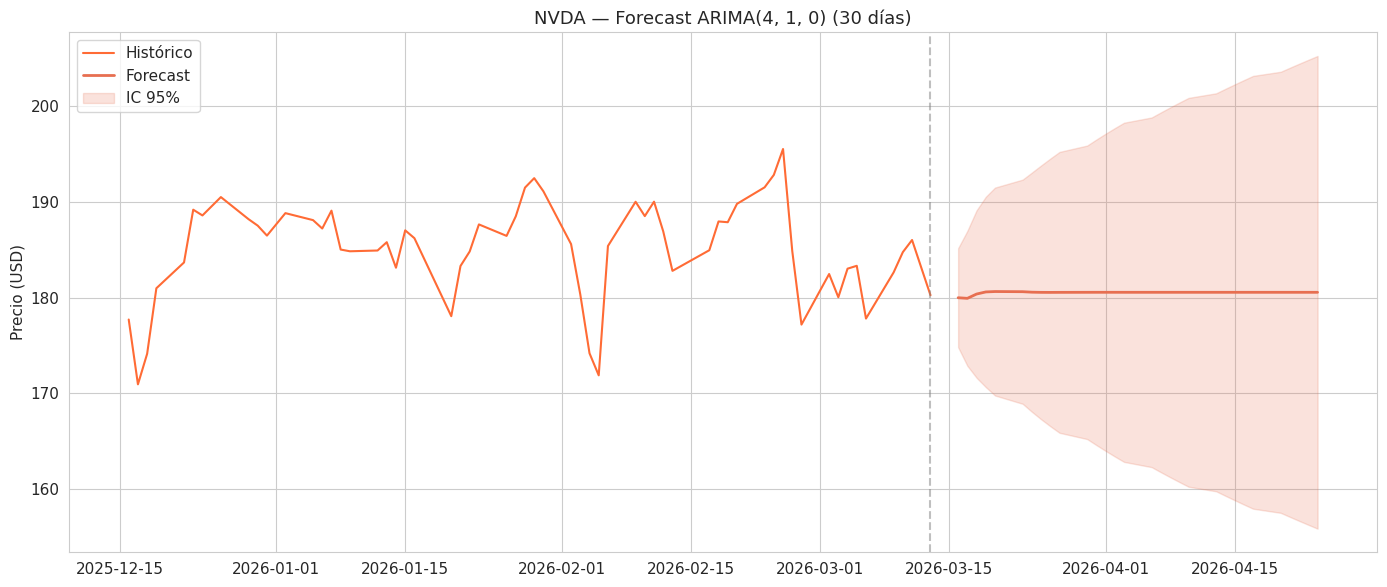


ANÁLISIS DE SERIES DE TIEMPO: AAPL
Observaciones: 1266 | Periodo: 2021-03-01 a 2026-03-13

--- Pruebas de Estacionariedad (precios de cierre) ---
ADF Statistic: -1.3615 | p-value: 0.6006 → NO estacionaria
KPSS Statistic: 0.4083 | p-value: 0.0100 → NO estacionaria


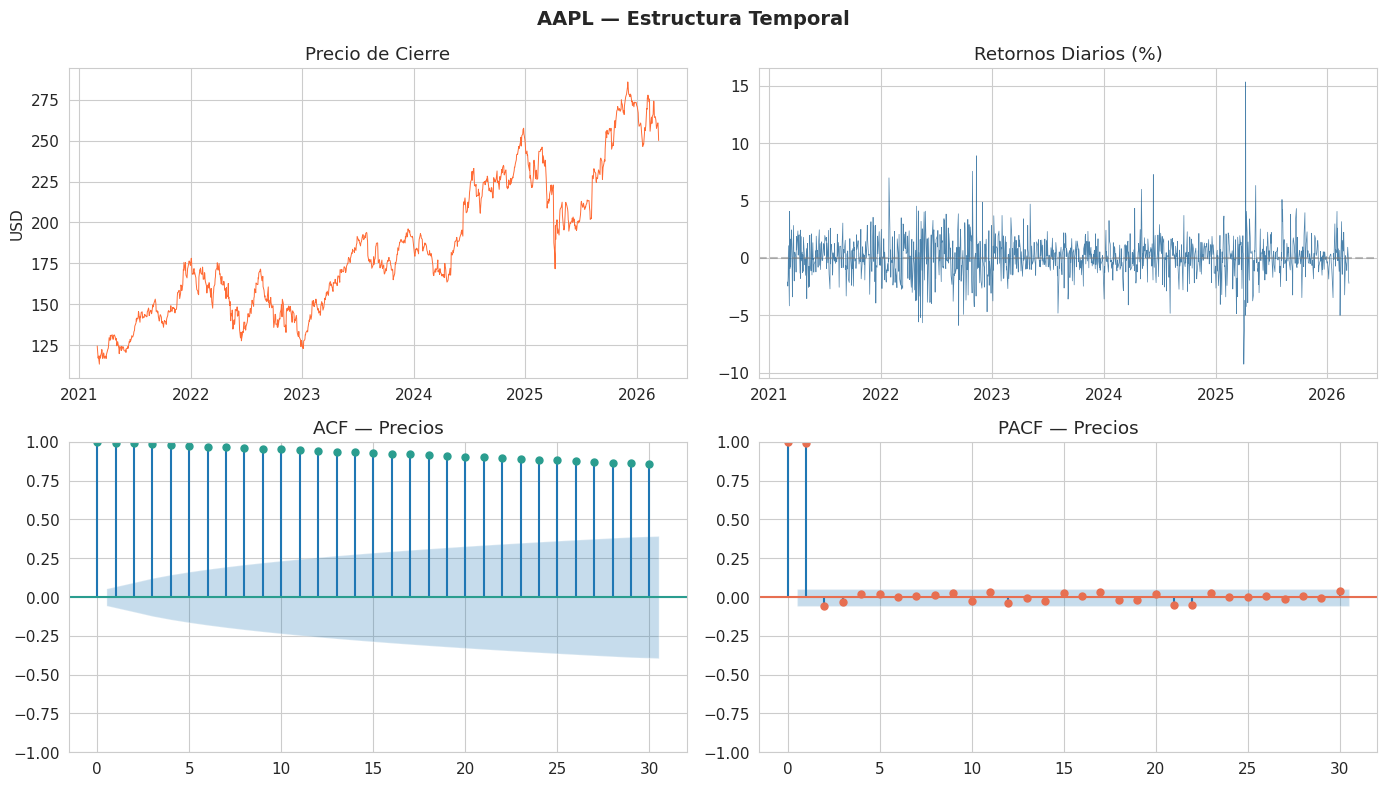


--- Selección de Modelo ARIMA (auto_arima) ---
Mejor modelo: ARIMA(1, 1, 0)
AIC: 6488.36
BIC: 6498.64

Resumen del modelo:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0517      0.017      2.995      0.003       0.018       0.086
sigma2         9.8554      0.190     51.903      0.000       9.483      10.228

Ljung-Box (lag 10): stat=4.04, p-value=0.9455

--- Forecast a 30 días ---
Último precio: $250.12
Forecast día 5: $249.81
Forecast día 15: $249.81
Forecast día 30: $249.81


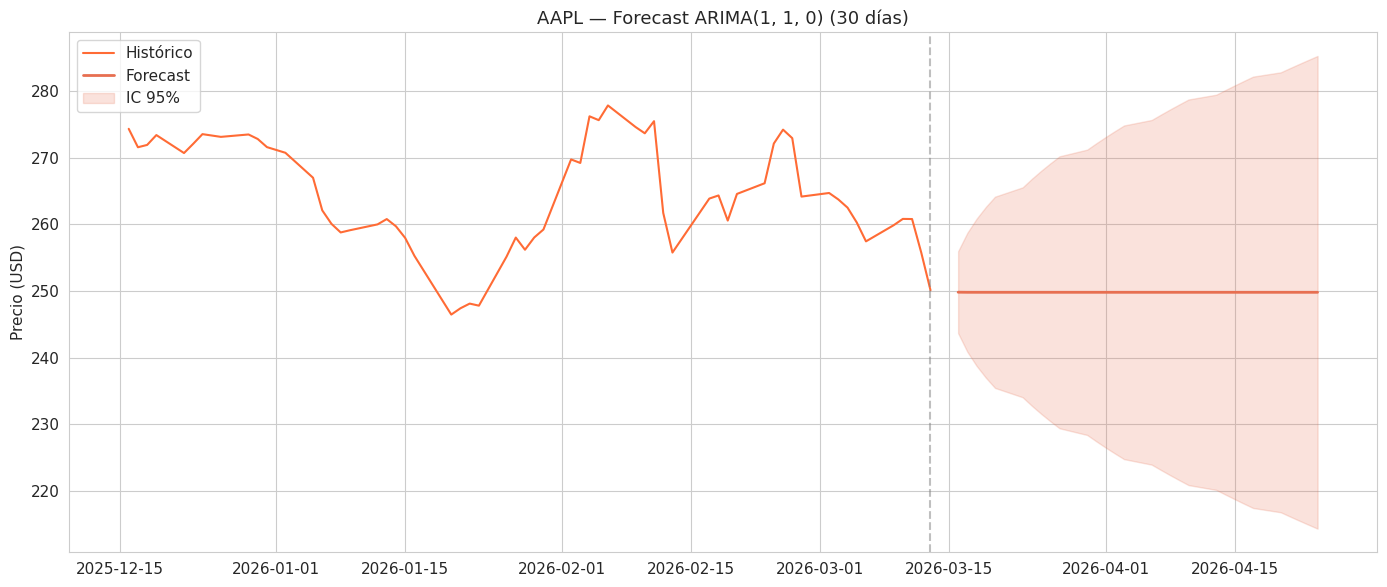


ANÁLISIS DE SERIES DE TIEMPO: META
Observaciones: 1266 | Periodo: 2021-03-01 a 2026-03-13

--- Pruebas de Estacionariedad (precios de cierre) ---
ADF Statistic: -0.7003 | p-value: 0.8467 → NO estacionaria
KPSS Statistic: 1.0521 | p-value: 0.0100 → NO estacionaria


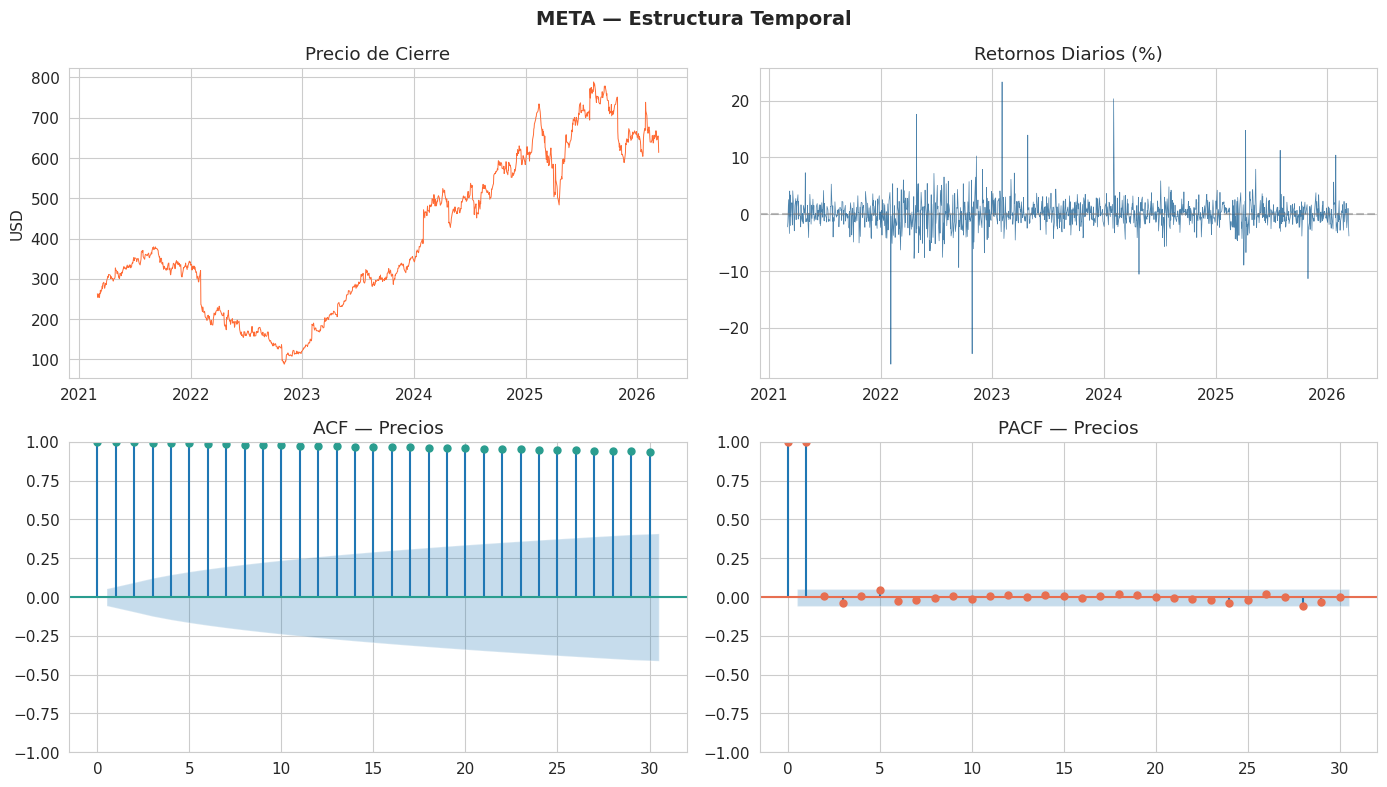


--- Selección de Modelo ARIMA (auto_arima) ---
Mejor modelo: ARIMA(1, 1, 0)
AIC: 9462.70
BIC: 9472.98

Resumen del modelo:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0539      0.020     -2.691      0.007      -0.093      -0.015
sigma2       103.5288      1.307     79.236      0.000     100.968     106.090

Ljung-Box (lag 10): stat=2.18, p-value=0.9947

--- Forecast a 30 días ---
Último precio: $613.71
Forecast día 5: $614.96
Forecast día 15: $614.96
Forecast día 30: $614.96


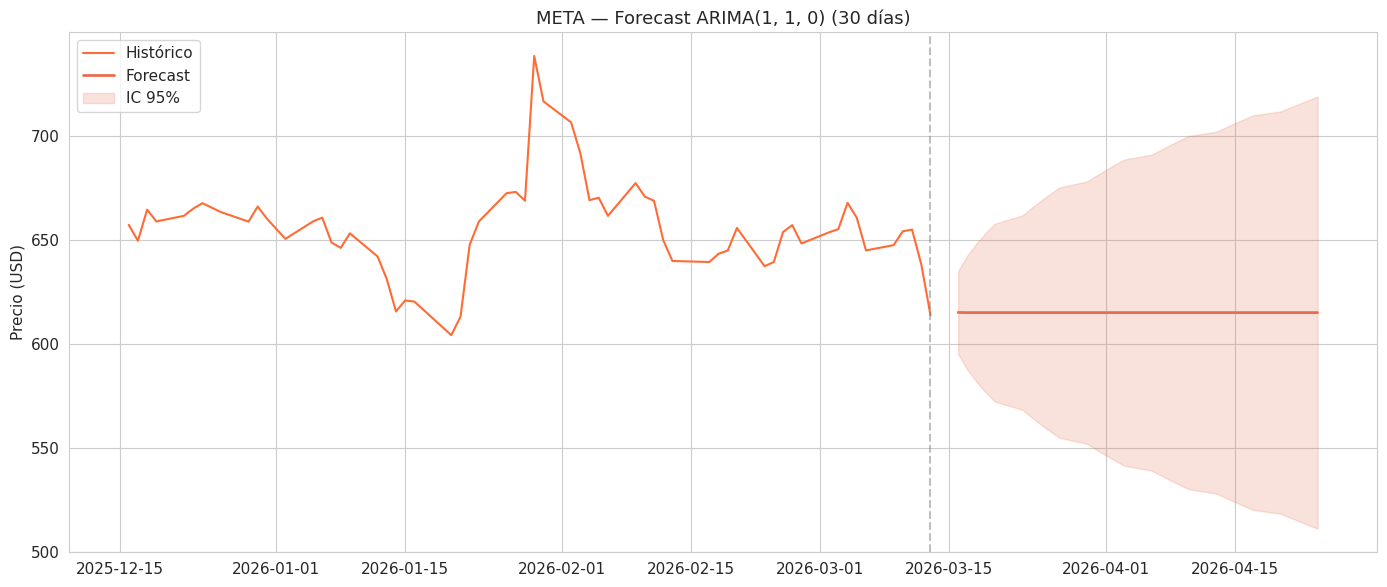


ANÁLISIS DE SERIES DE TIEMPO: AMD
Observaciones: 1266 | Periodo: 2021-03-01 a 2026-03-13

--- Pruebas de Estacionariedad (precios de cierre) ---
ADF Statistic: -1.3235 | p-value: 0.6184 → NO estacionaria
KPSS Statistic: 0.3562 | p-value: 0.0100 → NO estacionaria


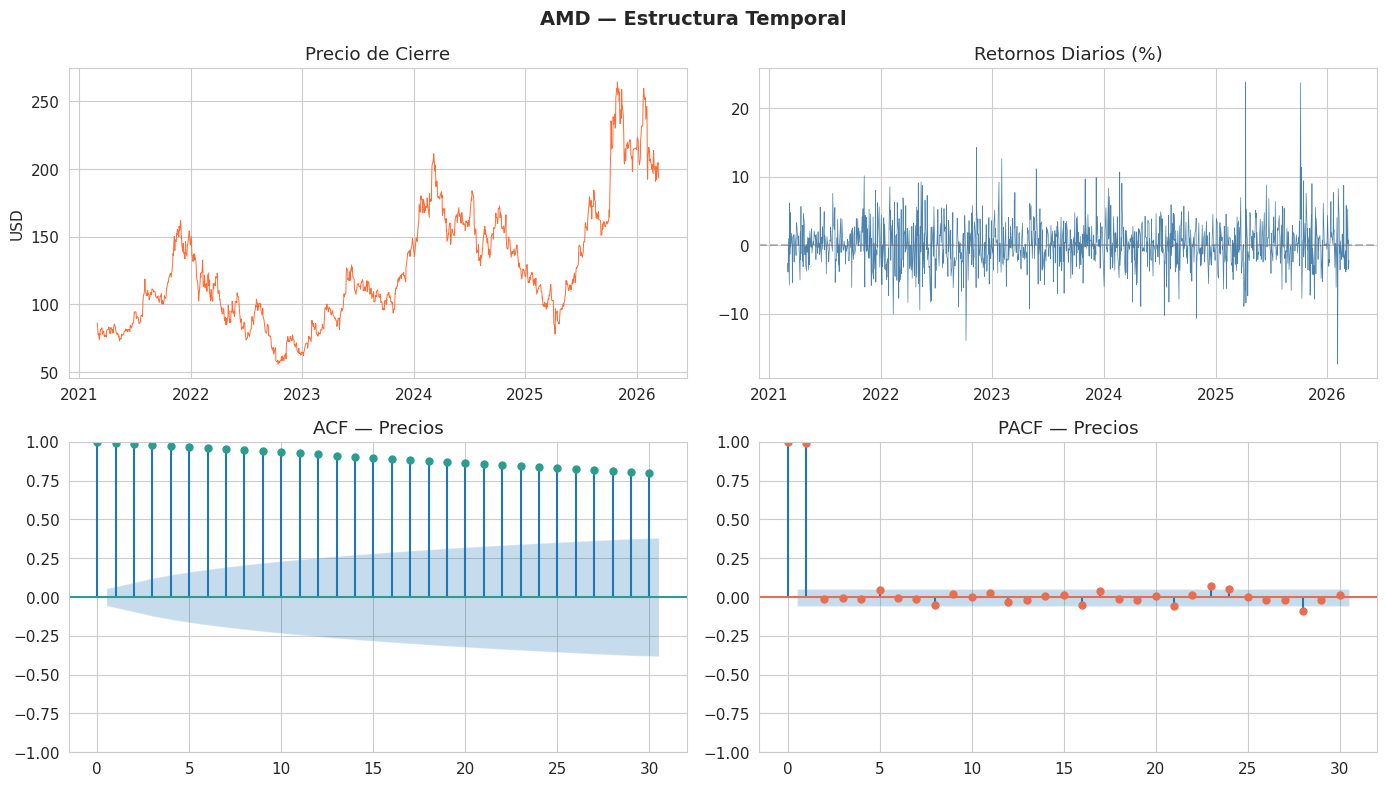


--- Selección de Modelo ARIMA (auto_arima) ---
Mejor modelo: ARIMA(0, 1, 0)
AIC: 7454.17
BIC: 7459.32

Resumen del modelo:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        21.1823      0.320     66.274      0.000      20.556      21.809

Ljung-Box (lag 10): stat=6.46, p-value=0.7751

--- Forecast a 30 días ---
Último precio: $193.39
Forecast día 5: $193.39
Forecast día 15: $193.39
Forecast día 30: $193.39


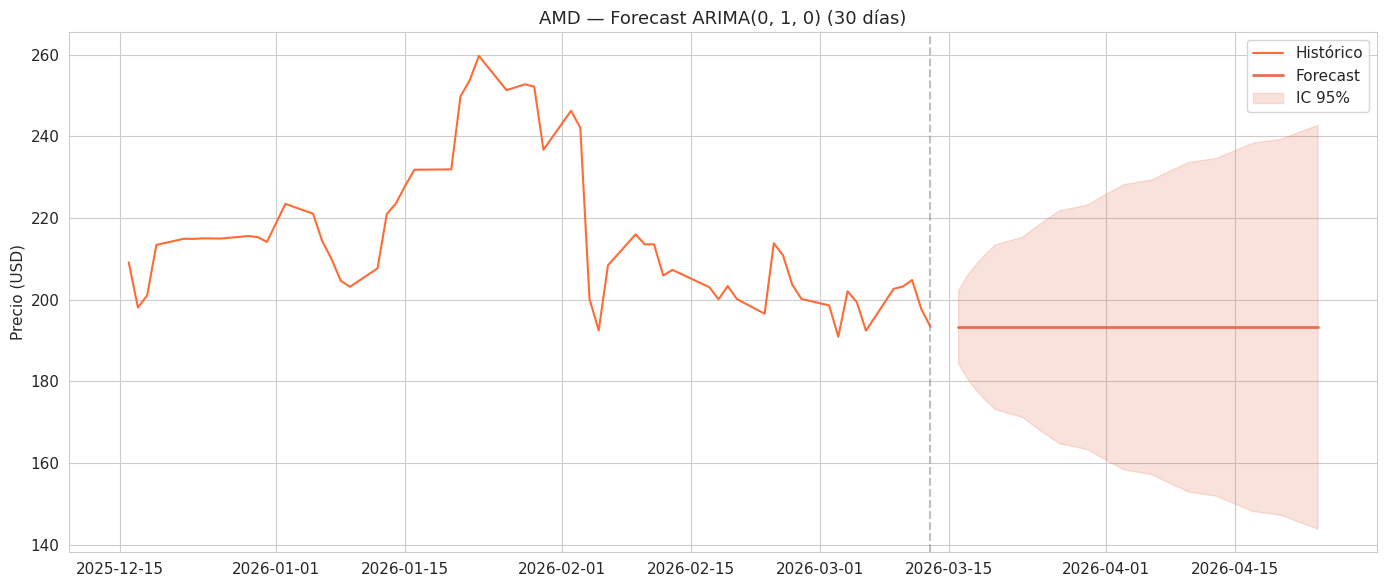


ANÁLISIS DE SERIES DE TIEMPO: INTC
Observaciones: 1266 | Periodo: 2021-03-01 a 2026-03-13

--- Pruebas de Estacionariedad (precios de cierre) ---
ADF Statistic: -2.1638 | p-value: 0.2196 → NO estacionaria
KPSS Statistic: 0.5345 | p-value: 0.0100 → NO estacionaria


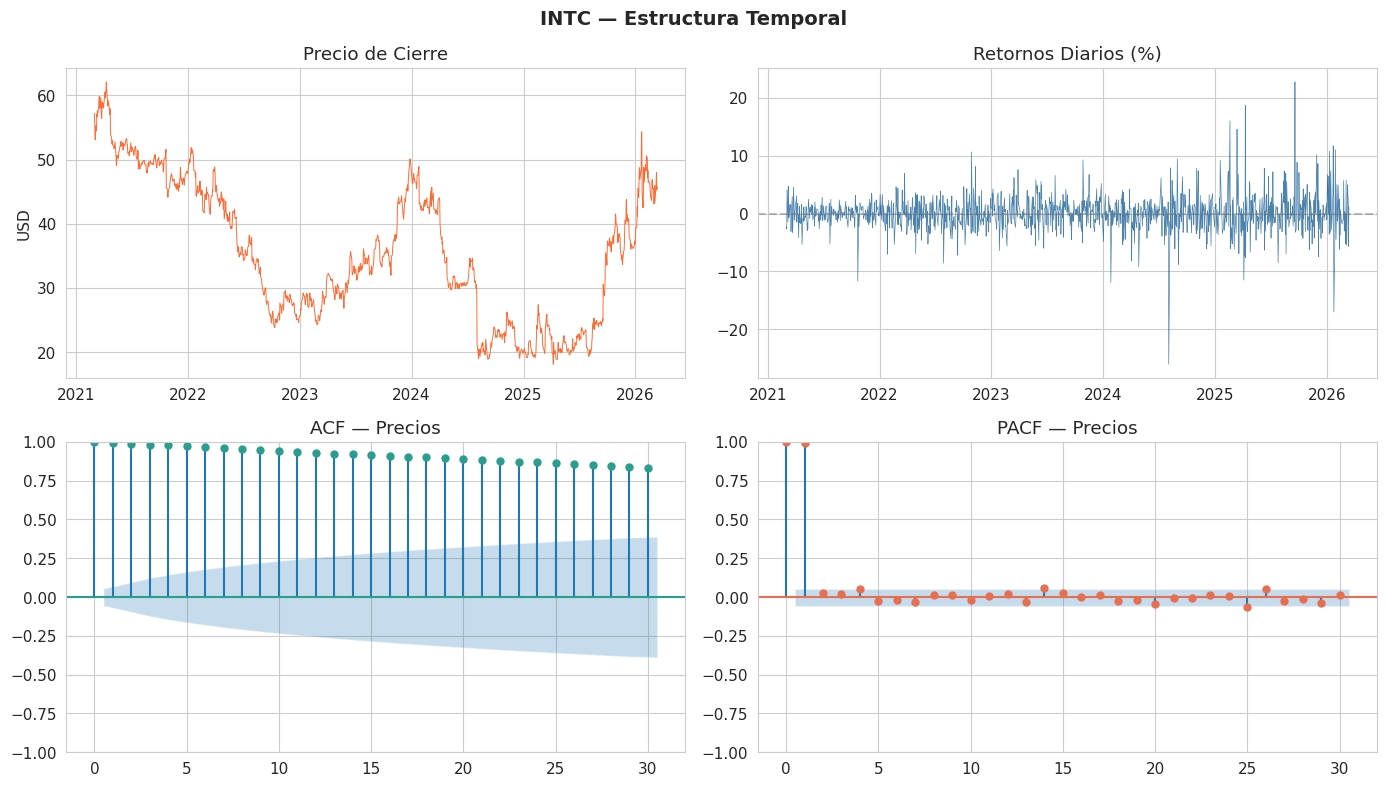


--- Selección de Modelo ARIMA (auto_arima) ---
Mejor modelo: ARIMA(0, 1, 0)
AIC: 3657.75
BIC: 3662.89

Resumen del modelo:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         1.0534      0.016     65.060      0.000       1.022       1.085

Ljung-Box (lag 10): stat=5.01, p-value=0.8904

--- Forecast a 30 días ---
Último precio: $45.77
Forecast día 5: $45.77
Forecast día 15: $45.77
Forecast día 30: $45.77


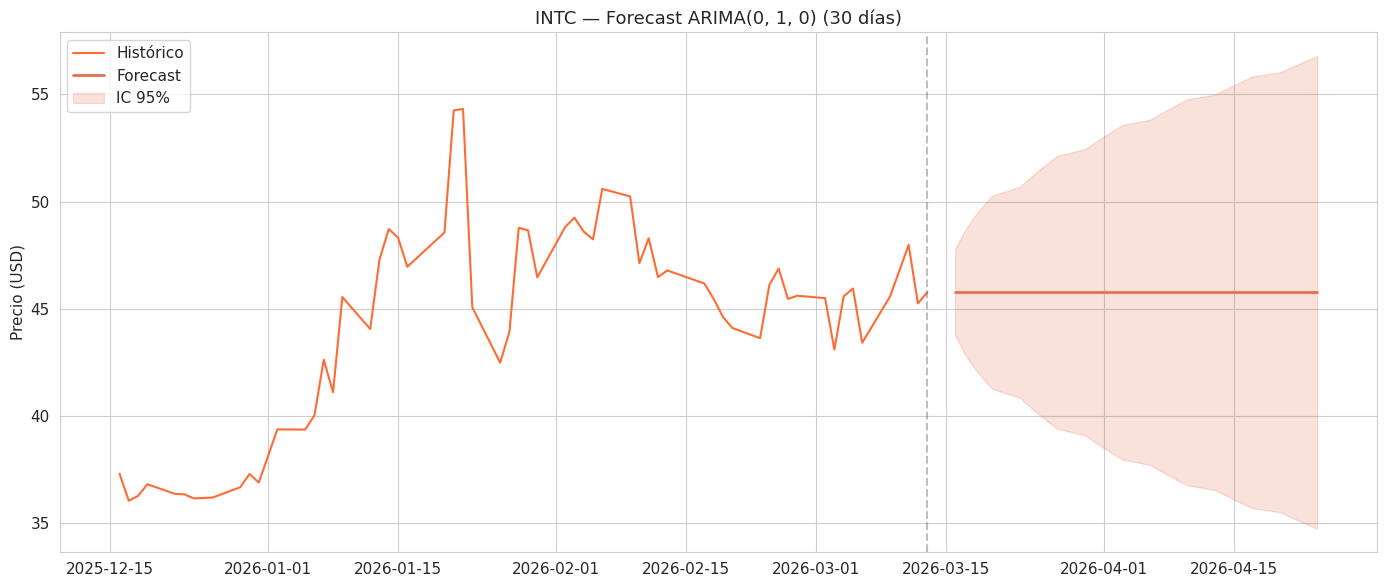


ANÁLISIS DE SERIES DE TIEMPO: PLTR
Observaciones: 1266 | Periodo: 2021-03-01 a 2026-03-13

--- Pruebas de Estacionariedad (precios de cierre) ---
ADF Statistic: 0.4428 | p-value: 0.9830 → NO estacionaria
KPSS Statistic: 1.2774 | p-value: 0.0100 → NO estacionaria


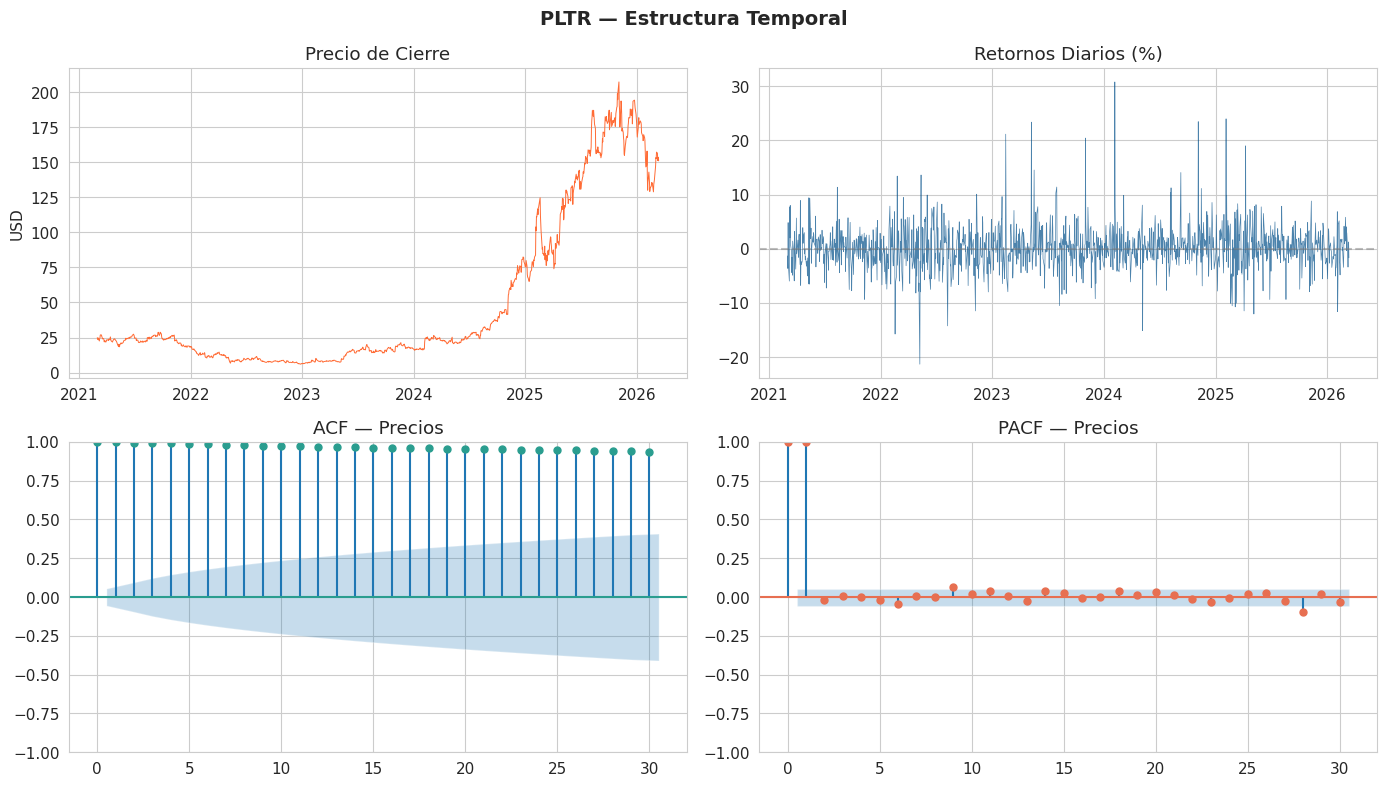


--- Selección de Modelo ARIMA (auto_arima) ---
Mejor modelo: ARIMA(0, 1, 0)
AIC: 6035.50
BIC: 6040.64

Resumen del modelo:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         6.9011      0.097     70.841      0.000       6.710       7.092

Ljung-Box (lag 10): stat=15.32, p-value=0.1207

--- Forecast a 30 días ---
Último precio: $150.95
Forecast día 5: $150.95
Forecast día 15: $150.95
Forecast día 30: $150.95


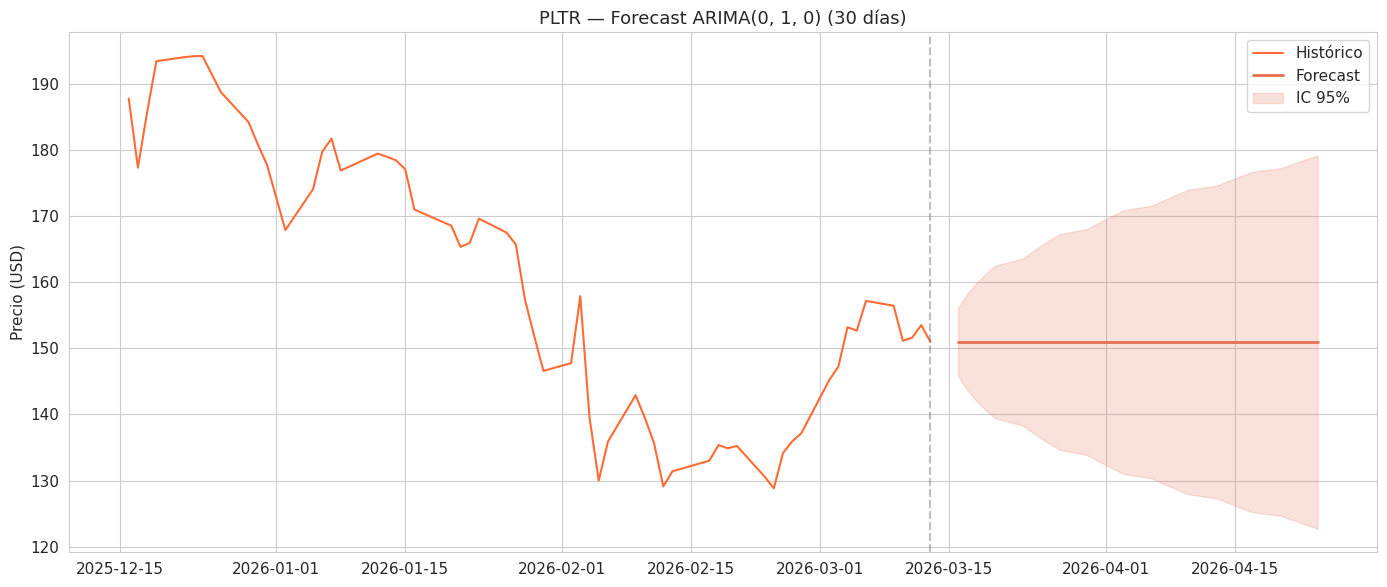


ANÁLISIS DE SERIES DE TIEMPO: LMT
Observaciones: 1266 | Periodo: 2021-03-01 a 2026-03-13

--- Pruebas de Estacionariedad (precios de cierre) ---
ADF Statistic: -0.4308 | p-value: 0.9048 → NO estacionaria
KPSS Statistic: 0.1642 | p-value: 0.0348 → NO estacionaria


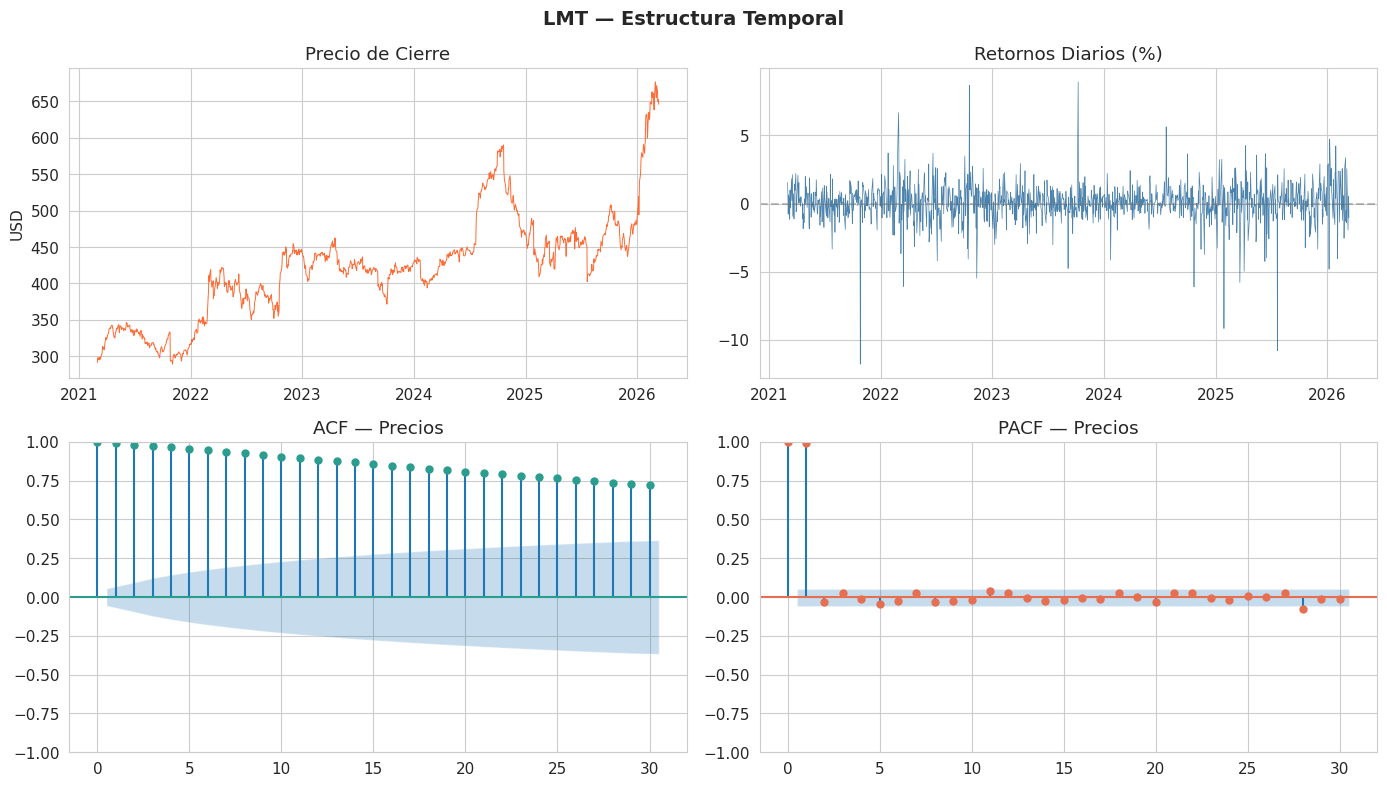


--- Selección de Modelo ARIMA (auto_arima) ---
Mejor modelo: ARIMA(0, 1, 2)
AIC: 8200.53
BIC: 8221.10

Resumen del modelo:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0436      0.021      2.066      0.039       0.002       0.085
ma.L2         -0.0399      0.023     -1.729      0.084      -0.085       0.005
sigma2        38.1102      0.616     61.903      0.000      36.904      39.317

Ljung-Box (lag 10): stat=1.42, p-value=0.9992

--- Forecast a 30 días ---
Último precio: $646.00
Forecast día 5: $645.86
Forecast día 15: $645.86
Forecast día 30: $645.86


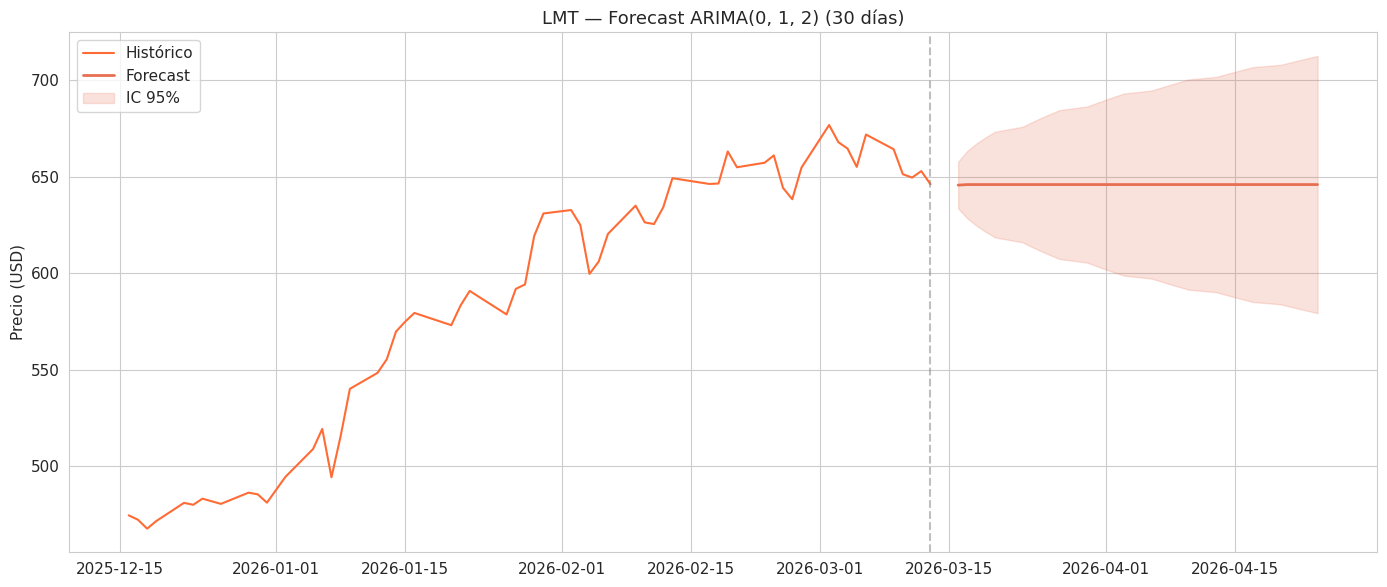


ANÁLISIS DE SERIES DE TIEMPO: GD
Observaciones: 1266 | Periodo: 2021-03-01 a 2026-03-13

--- Pruebas de Estacionariedad (precios de cierre) ---
ADF Statistic: -0.3885 | p-value: 0.9120 → NO estacionaria
KPSS Statistic: 0.3718 | p-value: 0.0100 → NO estacionaria


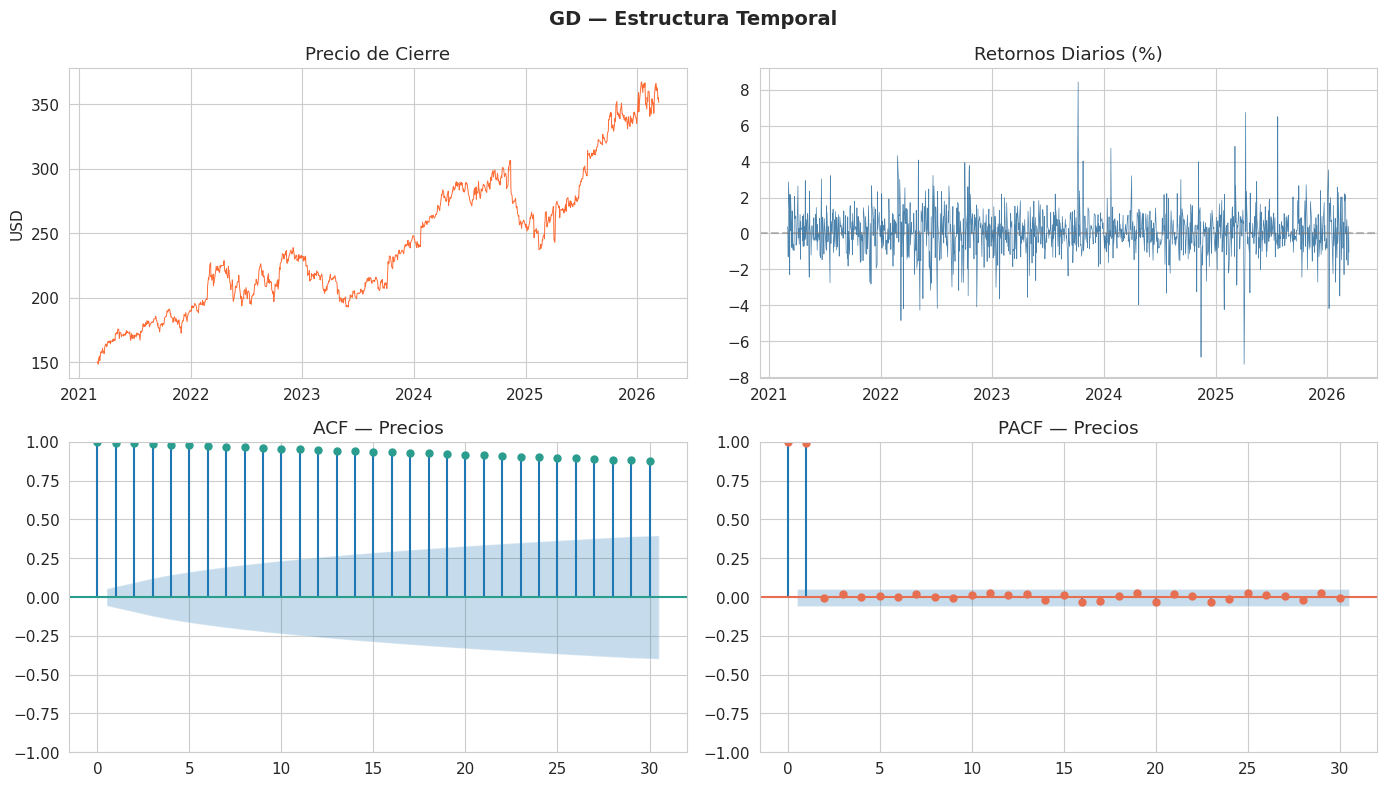


--- Selección de Modelo ARIMA (auto_arima) ---
Mejor modelo: ARIMA(2, 1, 2)
AIC: 6469.94
BIC: 6500.80

Resumen del modelo:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7885      0.045     40.162      0.000       1.701       1.876
ar.L2         -0.9025      0.040    -22.411      0.000      -0.981      -0.824
ma.L1         -1.8123      0.046    -39.717      0.000      -1.902      -1.723
ma.L2          0.9090      0.042     21.415      0.000       0.826       0.992
sigma2         9.6880      0.216     44.914      0.000       9.265      10.111

Ljung-Box (lag 10): stat=1.99, p-value=0.9964

--- Forecast a 30 días ---
Último precio: $351.52
Forecast día 5: $354.78
Forecast día 15: $352.90
Forecast día 30: $353.90


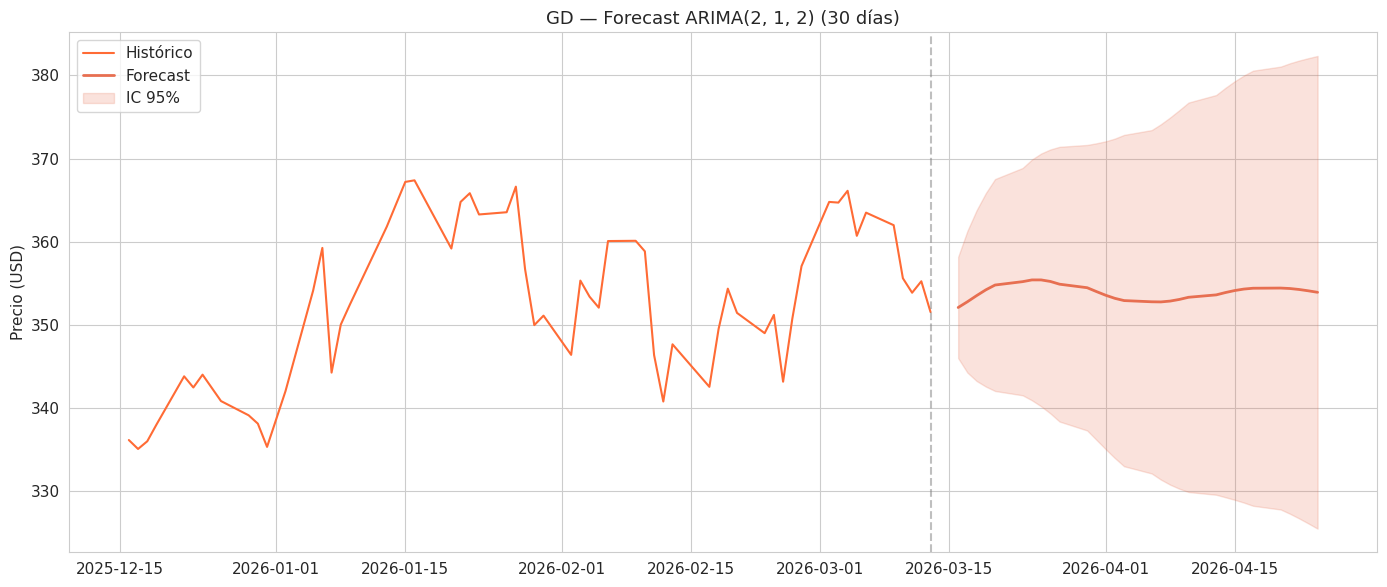


ANÁLISIS DE SERIES DE TIEMPO: JPM
Observaciones: 1266 | Periodo: 2021-03-01 a 2026-03-13

--- Pruebas de Estacionariedad (precios de cierre) ---
ADF Statistic: -0.1453 | p-value: 0.9447 → NO estacionaria
KPSS Statistic: 1.3246 | p-value: 0.0100 → NO estacionaria


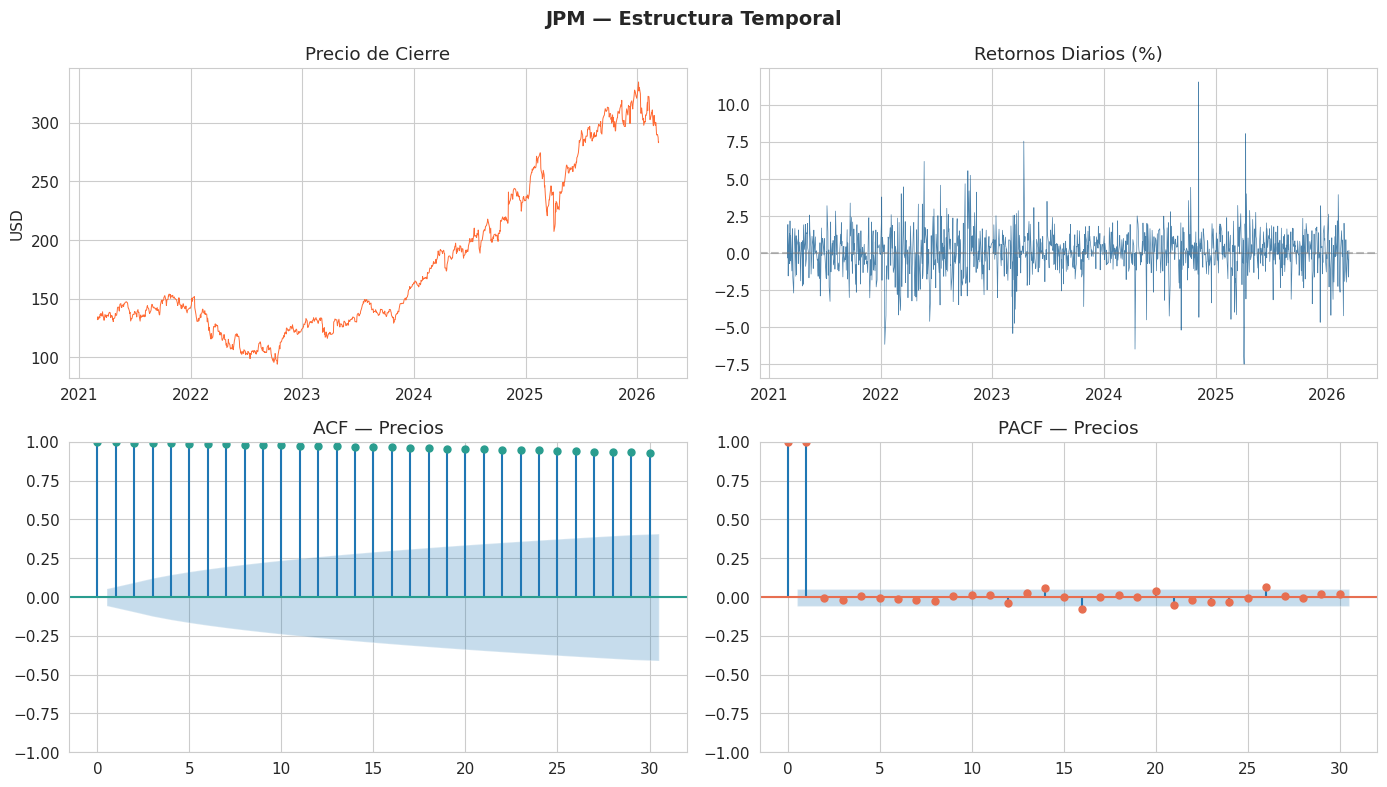


--- Selección de Modelo ARIMA (auto_arima) ---
Mejor modelo: ARIMA(2, 1, 2)
AIC: 6262.39
BIC: 6293.24

Resumen del modelo:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2214      0.019    -11.597      0.000      -0.259      -0.184
ar.L2         -0.9663      0.018    -54.630      0.000      -1.001      -0.932
ma.L1          0.2447      0.018     13.389      0.000       0.209       0.281
ma.L2          0.9728      0.017     57.246      0.000       0.939       1.006
sigma2         8.2037      0.142     57.582      0.000       7.924       8.483

Ljung-Box (lag 10): stat=2.84, p-value=0.9850

--- Forecast a 30 días ---
Último precio: $283.44
Forecast día 5: $283.41
Forecast día 15: $283.43
Forecast día 30: $283.42


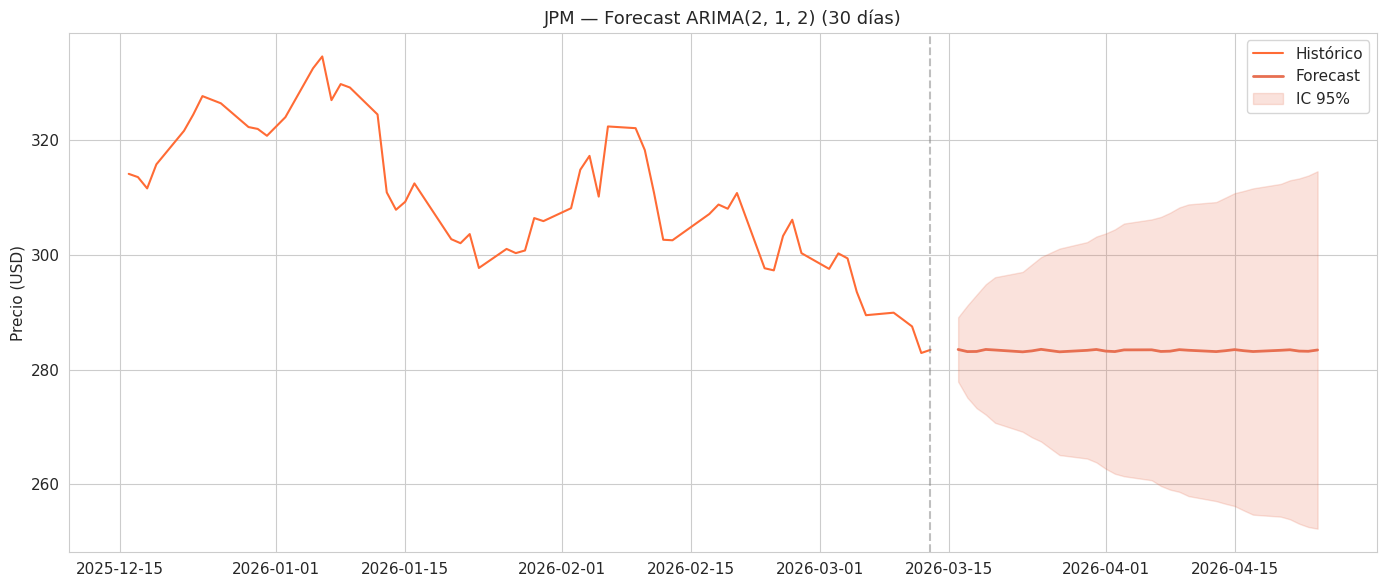


ANÁLISIS DE SERIES DE TIEMPO: JNJ
Observaciones: 1266 | Periodo: 2021-03-01 a 2026-03-13

--- Pruebas de Estacionariedad (precios de cierre) ---
ADF Statistic: 1.5891 | p-value: 0.9978 → NO estacionaria
KPSS Statistic: 0.7297 | p-value: 0.0100 → NO estacionaria


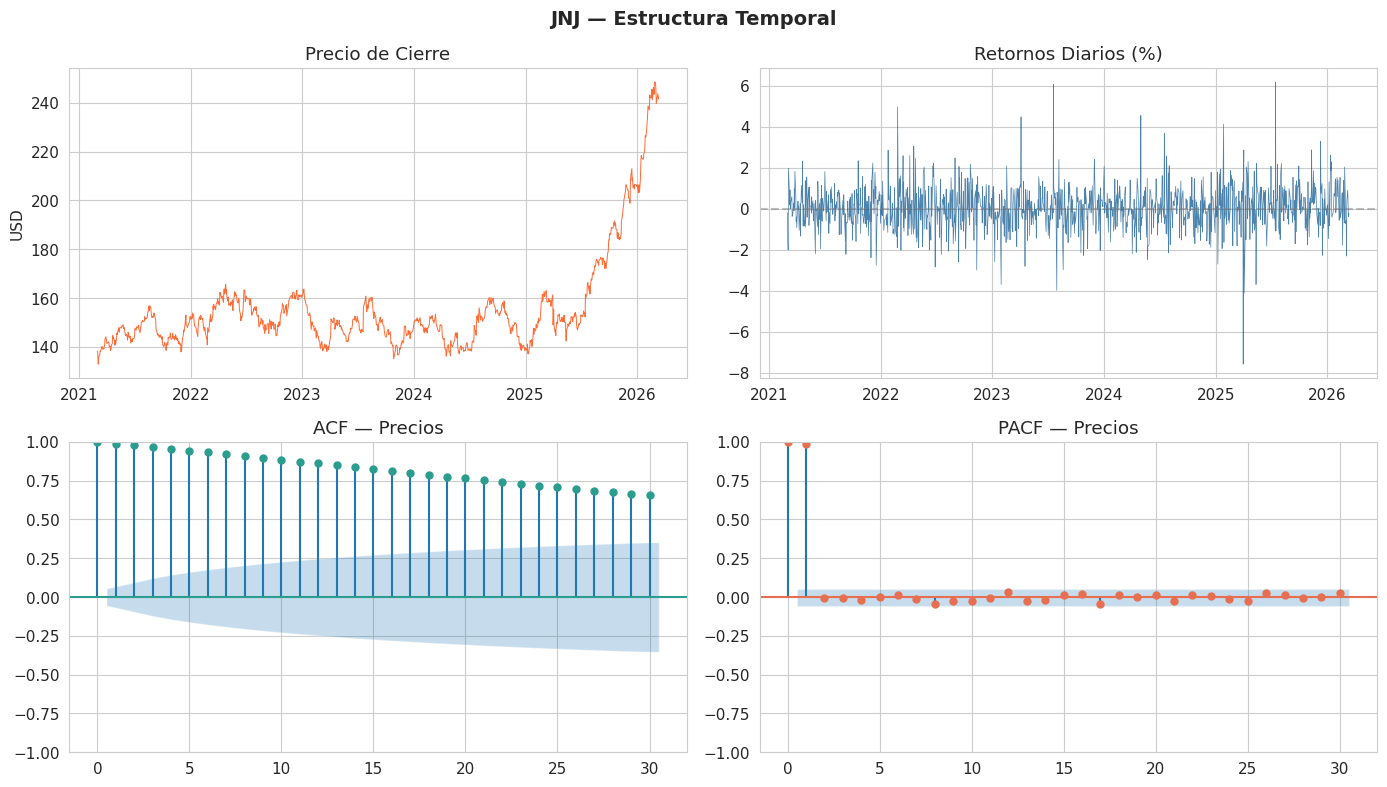


--- Selección de Modelo ARIMA (auto_arima) ---
Mejor modelo: ARIMA(5, 2, 0)
AIC: 5027.64
BIC: 5058.49

Resumen del modelo:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8542      0.025    -34.496      0.000      -0.903      -0.806
ar.L2         -0.7244      0.033    -22.251      0.000      -0.788      -0.661
ar.L3         -0.5442      0.036    -14.983      0.000      -0.615      -0.473
ar.L4         -0.3583      0.033    -10.958      0.000      -0.422      -0.294
ar.L5         -0.1935      0.025     -7.665      0.000      -0.243      -0.144
sigma2         3.0934      0.073     42.641      0.000       2.951       3.236

Ljung-Box (lag 10): stat=150.49, p-value=0.0000

--- Forecast a 30 días ---
Último precio: $241.52
Forecast día 5: $241.63
Forecast día 15: $240.89
Forecast día 30: $239.63


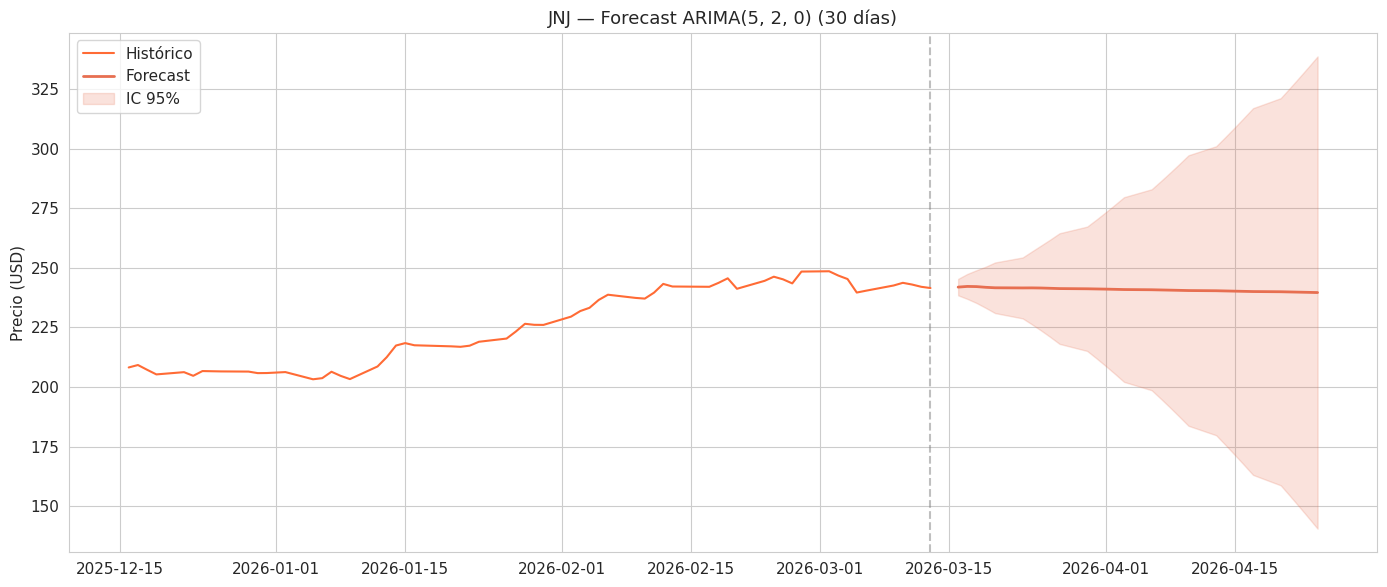


ANÁLISIS DE SERIES DE TIEMPO: XOM
Observaciones: 1266 | Periodo: 2021-03-01 a 2026-03-13

--- Pruebas de Estacionariedad (precios de cierre) ---
ADF Statistic: -0.3594 | p-value: 0.9167 → NO estacionaria
KPSS Statistic: 0.8202 | p-value: 0.0100 → NO estacionaria


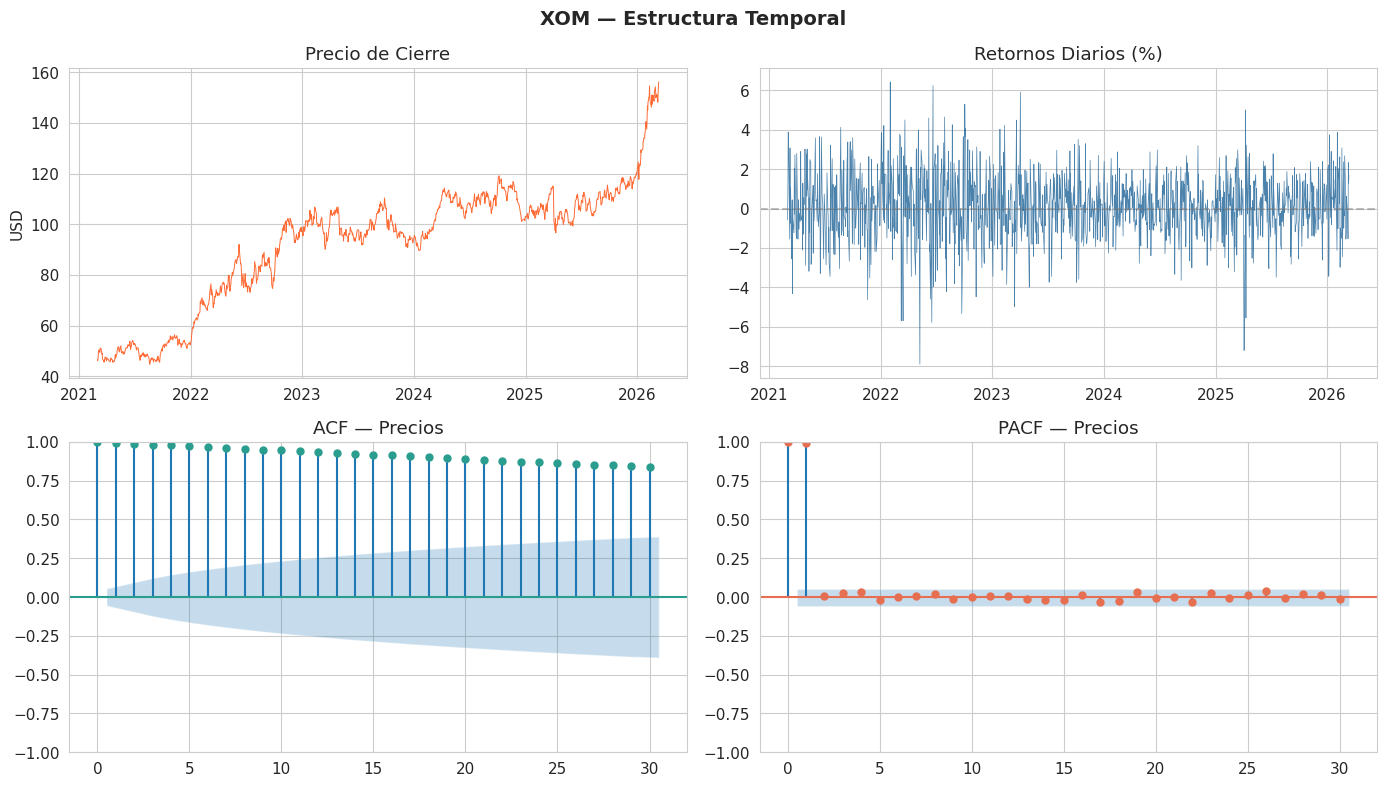


--- Selección de Modelo ARIMA (auto_arima) ---
Mejor modelo: ARIMA(0, 1, 0)
AIC: 4652.45
BIC: 4662.74

Resumen del modelo:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         2.3164      0.070     33.249      0.000       2.180       2.453

Ljung-Box (lag 10): stat=4.79, p-value=0.9049

--- Forecast a 30 días ---
Último precio: $156.12
Forecast día 5: $156.12
Forecast día 15: $156.12
Forecast día 30: $156.12


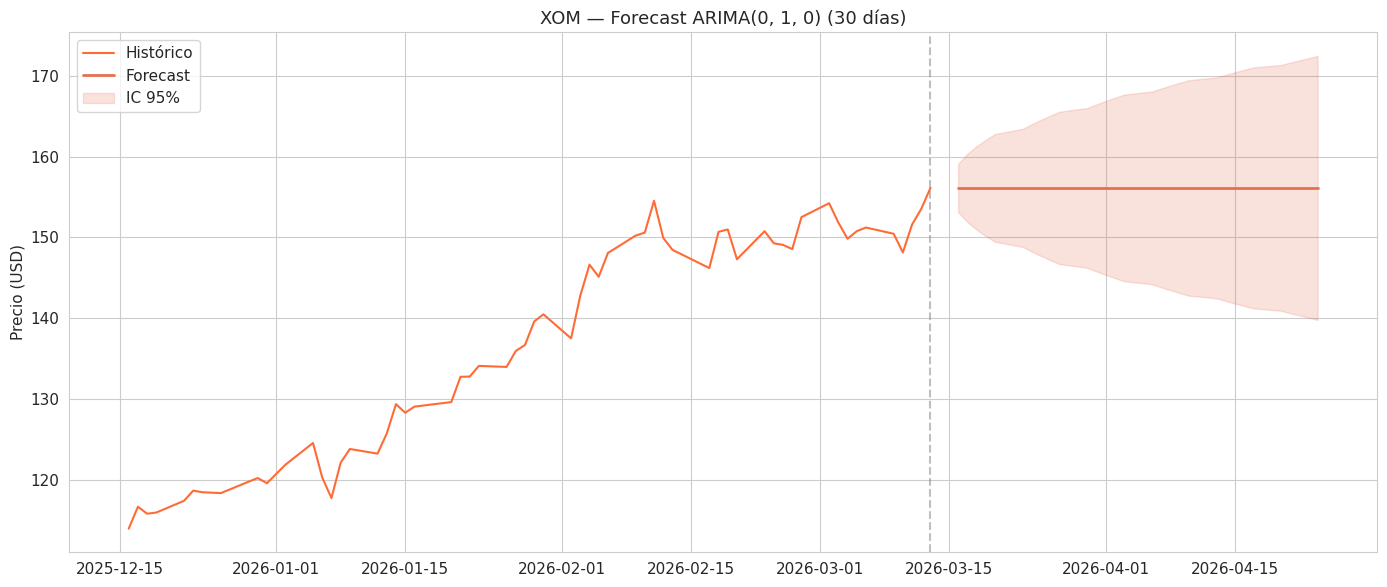

In [20]:
# Correr análisis para las 11 acciones
resultados_ts = []
for tk in tickers:
    try:
        res = analizar_accion(tk, precios)
        resultados_ts.append(res)
    except Exception as e:
        print(f"Error en {tk}: {e}")


## 7. Resumen de resultados — Series de Tiempo


In [21]:
# Tabla resumen
df_resumen = pd.DataFrame(resultados_ts)
df_resumen['Estacionaria_ADF'] = df_resumen['adf_pval'].apply(lambda x: 'Sí' if x < 0.05 else 'No')
df_resumen['Estacionaria_KPSS'] = df_resumen['kpss_pval'].apply(lambda x: 'No' if x < 0.05 else 'Sí')
df_resumen['ARIMA'] = df_resumen['order'].apply(lambda x: f"({x[0]},{x[1]},{x[2]})")
df_resumen['Forecast_30d'] = df_resumen['forecast_30d'].round(2)
df_resumen['Ultimo_Precio'] = df_resumen['last_price'].round(2)
df_resumen['Cambio_%'] = ((df_resumen['forecast_30d'] / df_resumen['last_price'] - 1) * 100).round(2)

print("Resumen de Modelos de Series de Tiempo")
print("=" * 90)
cols_show = ['ticker', 'Estacionaria_ADF', 'Estacionaria_KPSS', 'ARIMA', 'aic',
             'Ultimo_Precio', 'Forecast_30d', 'Cambio_%']
print(df_resumen[cols_show].to_string(index=False))


Resumen de Modelos de Series de Tiempo
ticker Estacionaria_ADF Estacionaria_KPSS   ARIMA         aic  Ultimo_Precio  Forecast_30d  Cambio_%
  NVDA               No                No (4,1,0) 6055.253981         180.25        180.56      0.17
  AAPL               No                No (1,1,0) 6488.356592         250.12        249.81     -0.12
  META               No                No (1,1,0) 9462.696477         613.71        614.96      0.20
   AMD               No                No (0,1,0) 7454.174645         193.39        193.39      0.00
  INTC               No                No (0,1,0) 3657.749168          45.77         45.77      0.00
  PLTR               No                No (0,1,0) 6035.499325         150.95        150.95      0.00
   LMT               No                No (0,1,2) 8200.532099         646.00        645.86     -0.02
    GD               No                No (2,1,2) 6469.943214         351.52        353.90      0.68
   JPM               No                No (2,1,2) 62

## 8. Análisis de Cointegración


In [22]:
# Prueba de cointegración por pares (Engle-Granger)
from itertools import combinations

print("Análisis de Cointegración por Pares")
print("=" * 50)

pares_coint = []
for t1, t2 in combinations(tickers, 2):
    if t1 not in precios.columns or t2 not in precios.columns:
        continue
    s1 = precios[t1].dropna()
    s2 = precios[t2].dropna()
    idx = s1.index.intersection(s2.index)
    s1, s2 = s1.loc[idx], s2.loc[idx]

    _, pval, _ = coint(s1, s2)
    pares_coint.append({'Par': f'{t1}-{t2}', 'p_value': round(pval, 4),
                        'Cointegrados': 'Sí' if pval < 0.05 else 'No'})

df_coint = pd.DataFrame(pares_coint)

# Mostrar solo los cointegrados primero
coint_si = df_coint[df_coint.Cointegrados == 'Sí'].sort_values('p_value')
print(f"\nPares cointegrados (p < 0.05): {len(coint_si)} de {len(df_coint)}")
if len(coint_si) > 0:
    print(coint_si.to_string(index=False))
else:
    print("Ningún par muestra cointegración significativa.")

print(f"\nTodos los pares:")
print(df_coint.sort_values('p_value').to_string(index=False))


Análisis de Cointegración por Pares

Pares cointegrados (p < 0.05): 3 de 55
      Par  p_value Cointegrados
 NVDA-JPM   0.0174           Sí
  LMT-XOM   0.0222           Sí
NVDA-AAPL   0.0282           Sí

Todos los pares:
      Par  p_value Cointegrados
 NVDA-JPM   0.0174           Sí
  LMT-XOM   0.0222           Sí
NVDA-AAPL   0.0282           Sí
   AMD-GD   0.0779           No
 AAPL-JPM   0.0877           No
  NVDA-GD   0.0879           No
  AAPL-GD   0.1238           No
 AAPL-AMD   0.1645           No
  AMD-JPM   0.1858           No
 AAPL-LMT   0.2015           No
AAPL-PLTR   0.2144           No
AAPL-META   0.2335           No
  AMD-JNJ   0.2861           No
   GD-JPM   0.3217           No
  AMD-LMT   0.3571           No
 META-JPM   0.3690           No
 AAPL-XOM   0.3697           No
 INTC-JNJ   0.3826           No
   GD-XOM   0.3887           No
NVDA-META   0.4067           No
 AMD-PLTR   0.4398           No
  LMT-JNJ   0.4493           No
  AMD-XOM   0.4664           No
INTC-PLTR 

---
# PARTE 3: GARCH — Modelado de Volatilidad (Puntos Extra)

Los modelos GARCH capturan la volatilidad condicional (clustering de volatilidad) que los modelos ARIMA no modelan. En series financieras, los periodos de alta volatilidad tienden a agruparse, lo cual es relevante para la gestión de riesgo del portafolio.


In [23]:
def analizar_garch(ticker, precios_df):
    """Modelo GARCH(1,1) para una acción."""
    serie = precios_df[ticker].dropna()
    retornos = serie.pct_change().dropna() * 100

    print(f"\n{'='*70}")
    print(f"GARCH(1,1): {ticker}")
    print(f"{'='*70}")

    # Ajustar GARCH(1,1)
    modelo = arch_model(retornos, vol='Garch', p=1, q=1, mean='AR', lags=1)
    resultado = modelo.fit(disp='off')
    print(resultado.summary())

    # Forecast de volatilidad a 10 días
    forecast = resultado.forecast(horizon=10)
    vol_forecast = np.sqrt(forecast.variance.iloc[-1].values)

    print(f"\nForecast de volatilidad (desv. est. diaria %):")
    for i, v in enumerate(vol_forecast):
        print(f"  Día {i+1}: {v:.2f}%")

    # Gráfica
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    axes[0].plot(retornos.index, retornos.values, color=palette[1], linewidth=0.4, alpha=0.7)
    axes[0].set_title(f'{ticker} — Retornos Diarios (%)')
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

    cond_vol = resultado.conditional_volatility
    axes[1].plot(cond_vol.index, cond_vol.values, color=palette[3], linewidth=0.7)
    axes[1].set_title(f'{ticker} — Volatilidad Condicional GARCH(1,1)')
    axes[1].set_ylabel('Volatilidad (%)')

    plt.suptitle(f'{ticker} — Análisis GARCH(1,1)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return resultado


Modelos GARCH(1,1) para las acciones más volátiles del portafolio:
(NVDA como dependiente + top 3 volátiles)


GARCH(1,1): NVDA
                           AR - GARCH Model Results                           
Dep. Variable:                   NVDA   R-squared:                       0.001
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3258.14
Distribution:                  Normal   AIC:                           6526.29
Method:            Maximum Likelihood   BIC:                           6552.00
                                        No. Observations:                 1264
Date:                Tue, Mar 17 2026   Df Residuals:                     1262
Time:                        02:39:13   Df Model:                            2
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----

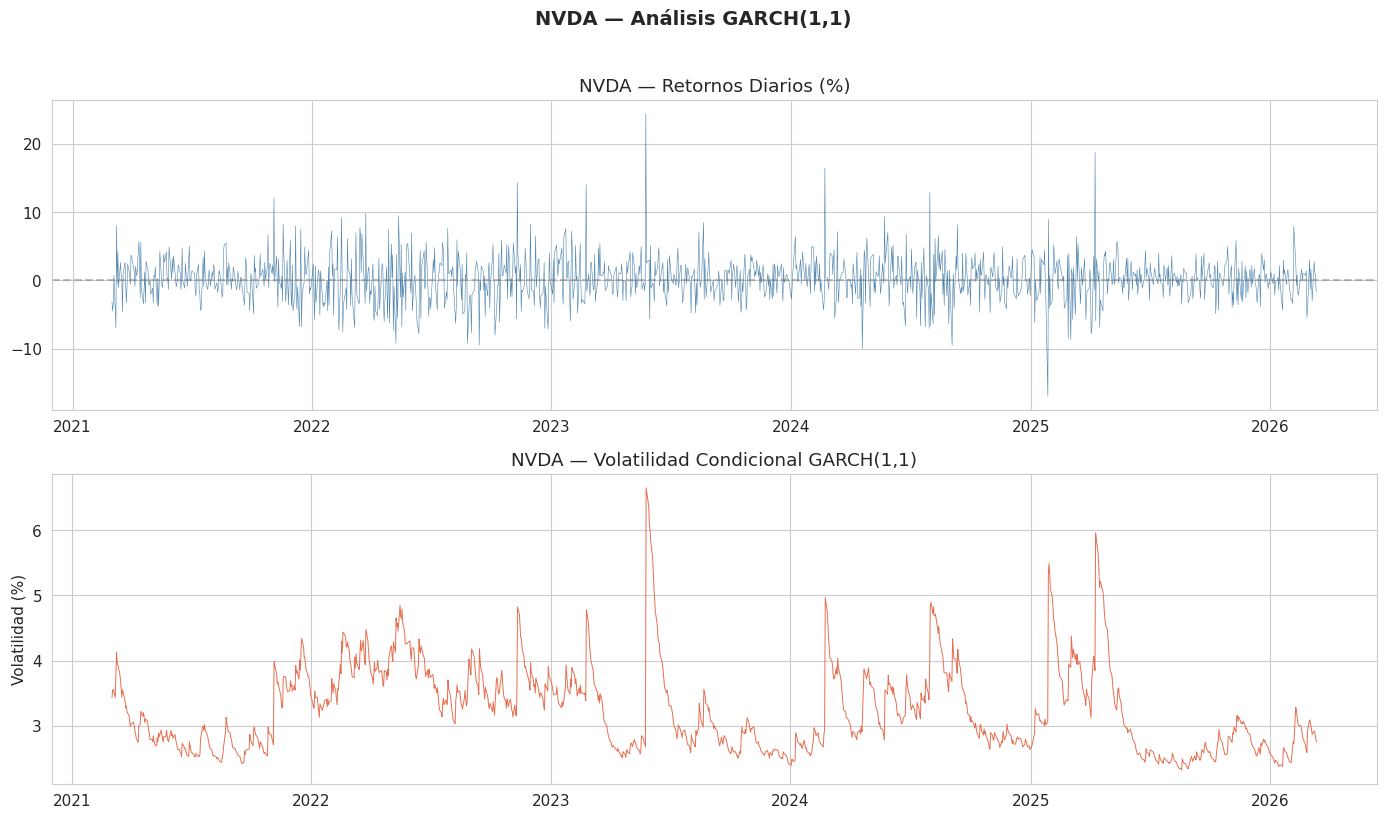


GARCH(1,1): PLTR
                           AR - GARCH Model Results                           
Dep. Variable:                   PLTR   R-squared:                       0.004
Mean Model:                        AR   Adj. R-squared:                  0.004
Vol Model:                      GARCH   Log-Likelihood:               -3573.79
Distribution:                  Normal   AIC:                           7157.57
Method:            Maximum Likelihood   BIC:                           7183.28
                                        No. Observations:                 1264
Date:                Tue, Mar 17 2026   Df Residuals:                     1262
Time:                        02:39:14   Df Model:                            2
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.2178      0.115      1.899

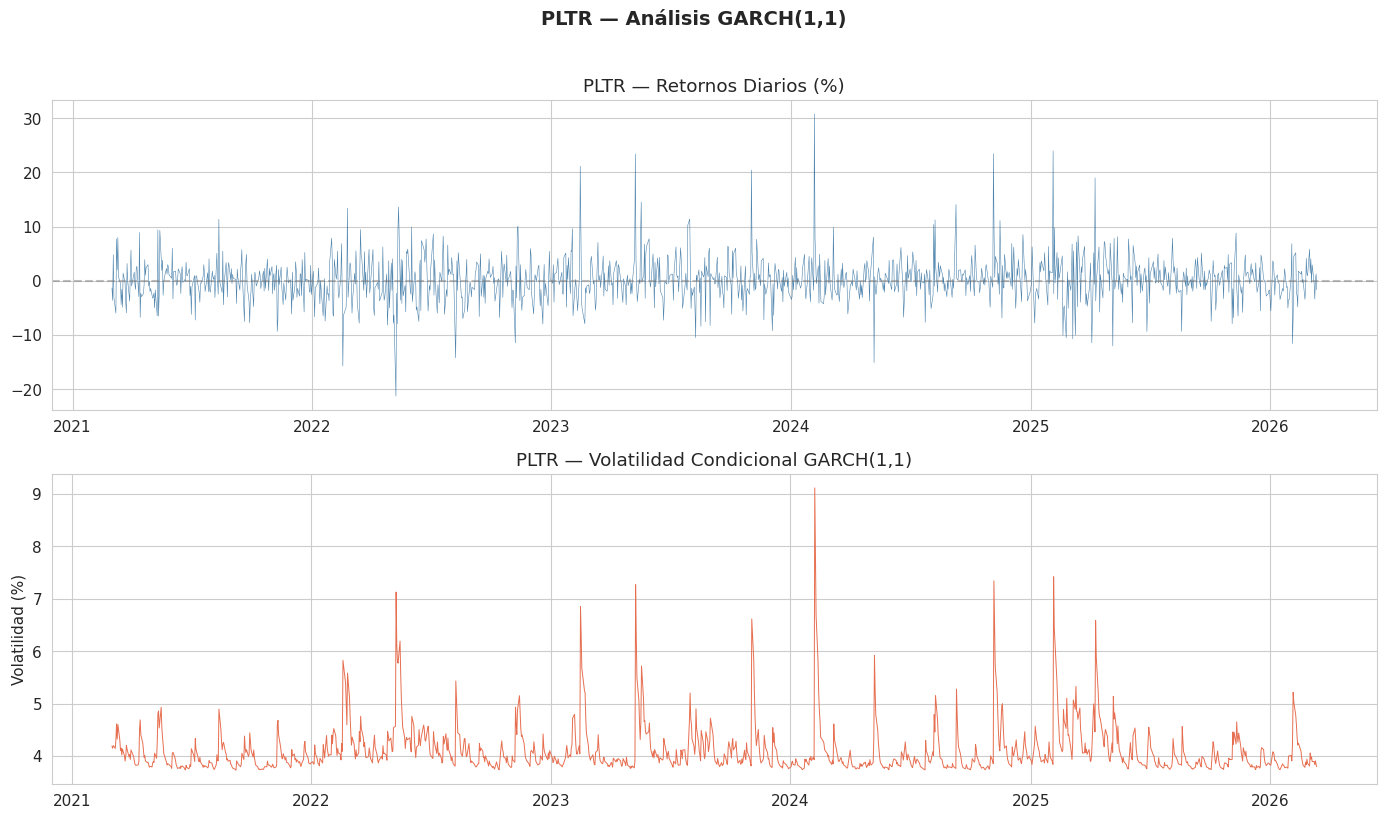


GARCH(1,1): AMD
                           AR - GARCH Model Results                           
Dep. Variable:                    AMD   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                 -0.001
Vol Model:                      GARCH   Log-Likelihood:               -3310.94
Distribution:                  Normal   AIC:                           6631.88
Method:            Maximum Likelihood   BIC:                           6657.59
                                        No. Observations:                 1264
Date:                Tue, Mar 17 2026   Df Residuals:                     1262
Time:                        02:39:14   Df Model:                            2
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
Const          0.1390  9.768e-02      

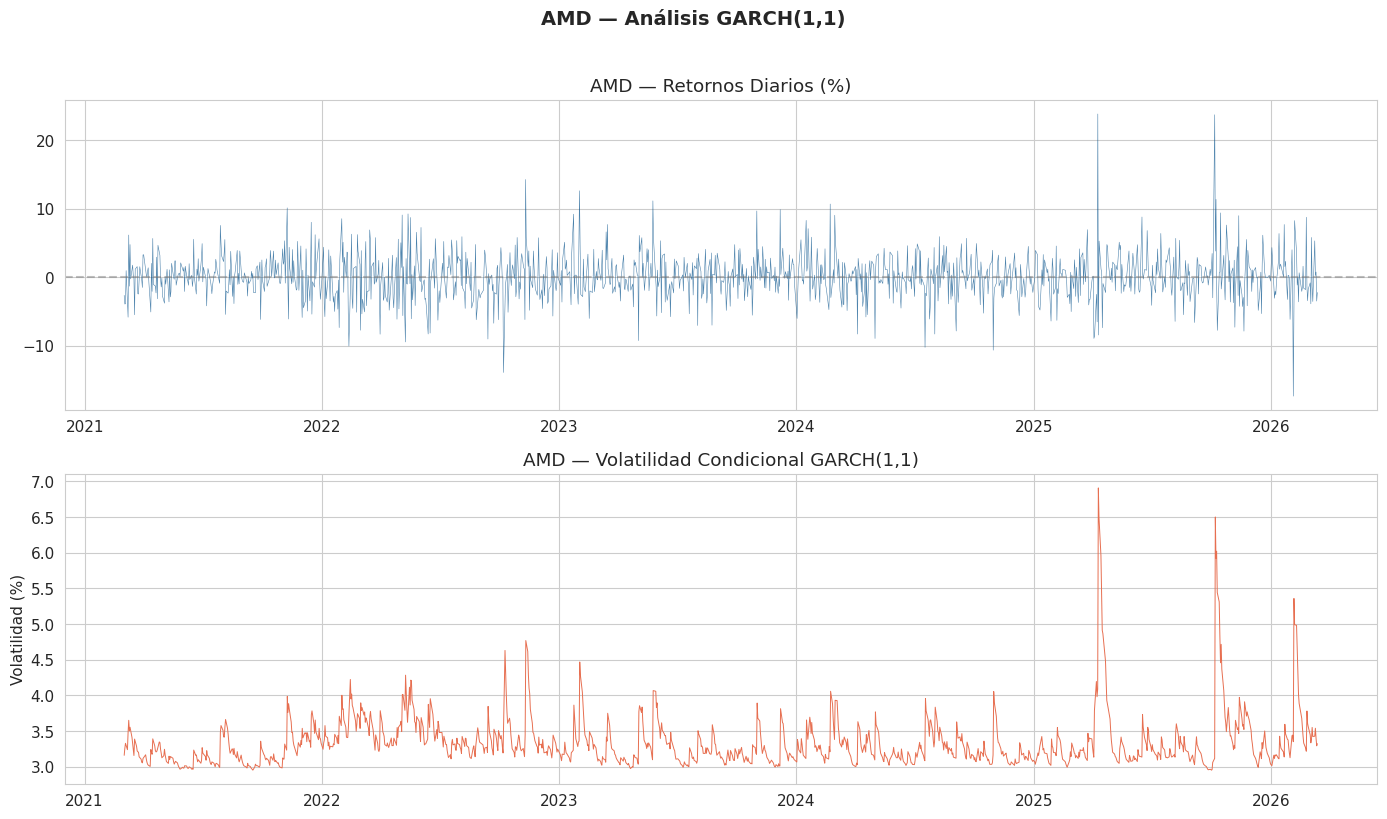


GARCH(1,1): META
                           AR - GARCH Model Results                           
Dep. Variable:                   META   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                 -0.001
Vol Model:                      GARCH   Log-Likelihood:               -3032.73
Distribution:                  Normal   AIC:                           6075.46
Method:            Maximum Likelihood   BIC:                           6101.17
                                        No. Observations:                 1264
Date:                Tue, Mar 17 2026   Df Residuals:                     1262
Time:                        02:39:15   Df Model:                            2
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.1407  9.833e-02      1.431

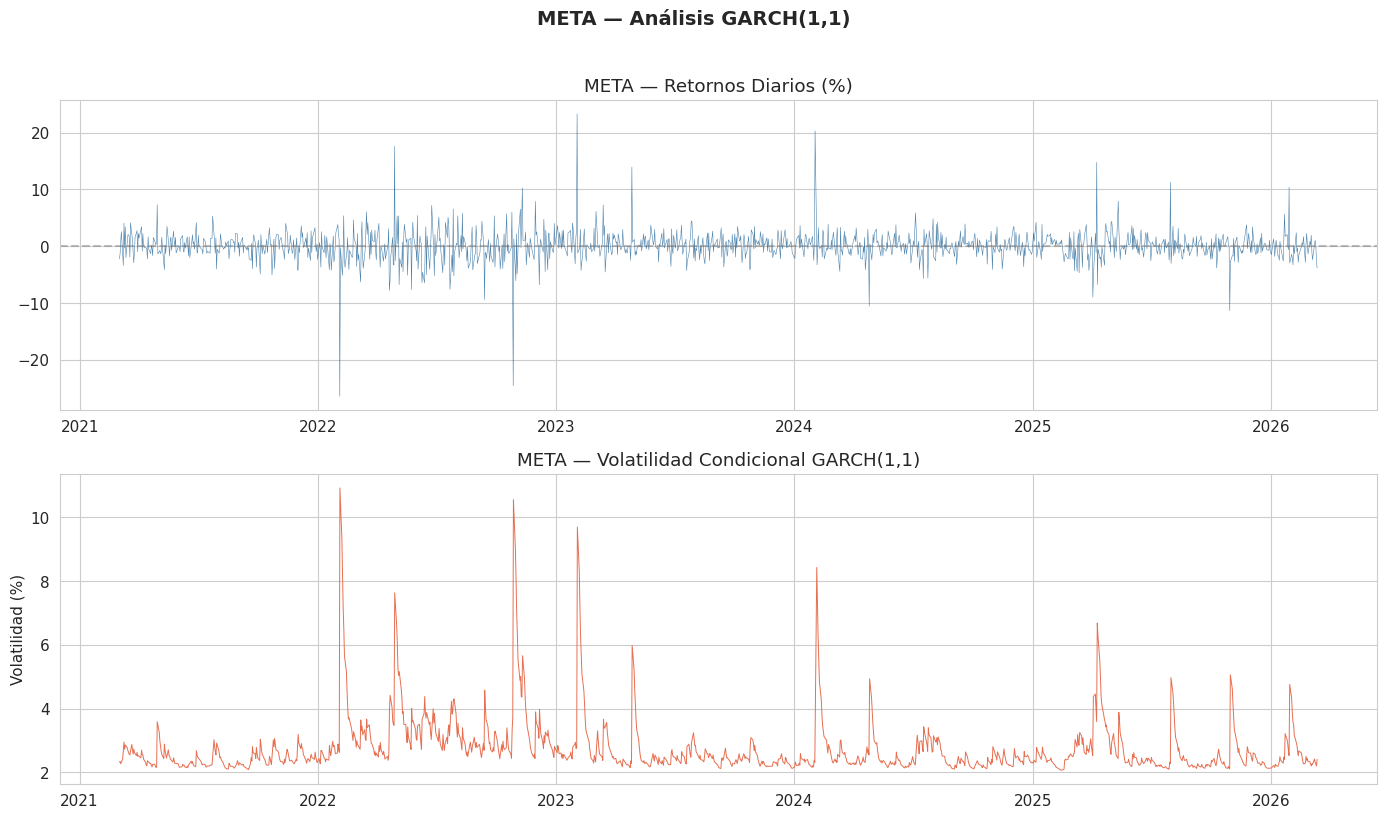

In [24]:
# Aplicar GARCH a las acciones más volátiles del portafolio
# (NVDA como variable dependiente + las más volátiles)
acciones_garch = ['NVDA', 'PLTR', 'AMD', 'META']

print("Modelos GARCH(1,1) para las acciones más volátiles del portafolio:")
print("(NVDA como dependiente + top 3 volátiles)\n")

resultados_garch = {}
for tk in acciones_garch:
    try:
        resultados_garch[tk] = analizar_garch(tk, precios)
    except Exception as e:
        print(f"Error en {tk}: {e}")


---
# Conclusiones Generales

## Panel Data
El análisis de panel data mostró la relación entre fundamentales trimestrales (revenue growth, márgenes, ROE) y los retornos bursátiles de las 11 empresas del portafolio, controlando por diferencias estructurales entre compañías mediante efectos fijos/aleatorios. Esto complementa la regresión de retornos diarios (R Markdown) al pasar de correlaciones de mercado a relaciones fundamental-precio.

## Series de Tiempo
Los modelos ARIMA capturaron la estructura temporal de cada acción, confirmando que la mayoría de los precios siguen procesos no estacionarios con alta persistencia (caminata aleatoria). Los forecasts a 30 días muestran la dirección esperada de cada acción con intervalos de confianza, útiles para la toma de decisiones tácticas en el portafolio de HowTheMarketWorks.

## GARCH
El modelado de volatilidad condicional reveló los clusters de volatilidad en las acciones tech/growth del portafolio, confirmando que NVDA, PLTR y AMD presentan periodos de volatilidad concentrada que impactan la gestión de riesgo.

## Conexión con HowTheMarketWorks
Los tres análisis convergen en que el portafolio está concentrado en acciones con alta persistencia temporal y volatilidad agrupada (sector tech/AI), mientras que las posiciones defensivas (JNJ, LMT, XOM) ofrecen diversificación real tanto en correlaciones diarias como en fundamentales trimestrales.

---
*Proyecto Final de Econometría | Maestría en Finanzas | EGADE Business School | Marzo 2026*  
*Datos: Refinitiv Workspace & Yahoo Finance*
